# Coupled flow–particle analysis

This notebook combines the Eulerian flow diagnostics with the saved Parcels trajectories.

Implemented diagnostics:

- conditional mean particle concentration in **Ro–strain** space;
- conditional **cluster probability** in **Ro–strain** space;
- conditional mean particle concentration in **divergence–strain** space;
- flow maps with **clustered particles only** overlaid on divergence / Rossby-number backgrounds;
- temporal evolution of **submesoscale activity** vs. **fraction of clustered particles**;
- temporal evolution of **mean particle concentration** in **AVD**, **CVD** and **strain-dominated** regimes.

The notebook is designed to remain extensible: all particle–flow quantities are cached into compact per-class datasets so that future coupled plots can reuse them directly.


In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import shutil
import importlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from IPython.display import display


NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent

PARCELS_DIR = PROJECT_DIR / "z.parcels_postprocessing"
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

for path in [PROJECT_DIR, FLOW_DIR, PARCELS_DIR, FLOW_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)


import scripts.fieldset as pfs
import scripts.run as prun
import scripts.metrics_clustering as mclus
import scripts.notebook_helpers as phelp
import theme.plot_theme as ptheme
import shcherbina_utils as shu

for module in [pfs, prun, mclus, phelp, ptheme, shu]:
    importlib.reload(module)

ptheme.apply_theme()
shu.apply_plot_style()

print(f"Notebook dir       : {NB_DIR}")
print(f"Project dir        : {PROJECT_DIR}")
print(f"Clustering module  : {Path(mclus.__file__).resolve()}")
print(f"Flow helper module : {Path(shu.__file__).resolve()}")


Notebook dir       : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\notebooks
Project dir        : C:\Users\Jelle Gortemaker\Documents\Thesis
Clustering module  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\scripts\metrics_clustering.py
Flow helper module : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\scripts\shcherbina_utils.py


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\

In [2]:
# ============================================================
# 2. CASE, COLLECTION AND PLOT SETTINGS
# ============================================================

case_name = "run_jun1_2D"
RUN_TITLE_INFO = "Case JUN-1 2D"

INPUT_DIR = (PARCELS_DIR / "data" / "input").resolve()
DATA_FILE = (INPUT_DIR / f"{case_name}.nc").resolve()

CASE_RESULTS_DIR = (PARCELS_DIR / "results" / case_name).resolve()
METADATA_DIR = CASE_RESULTS_DIR / "metadata"
METRICS_DIR = CASE_RESULTS_DIR / "metrics"

# Set to None to use the newest collection configuration.
RUN_COLLECTION_ID = None

if RUN_COLLECTION_ID is None:
    configs = sorted(
        METADATA_DIR.glob("*_config.json"),
        key=lambda p: p.stat().st_mtime,
    )
    if len(configs) == 0:
        raise FileNotFoundError(
            f"No run collection configuration found in:\n{METADATA_DIR}"
        )
    CONFIG_JSON = configs[-1]
else:
    CONFIG_JSON = METADATA_DIR / f"{RUN_COLLECTION_ID}_config.json"

if not CONFIG_JSON.exists():
    raise FileNotFoundError(f"Could not find collection config:\n{CONFIG_JSON}")


# ------------------------------------------------------------
# Particle classes
# ------------------------------------------------------------
INCLUDE_TAGS = None
INCLUDE_PARTICLE_CLASSES = None
STOKES_RANGE = None
TAU_P_RANGE_SECONDS = None
LABEL_OVERRIDES = {}


# ------------------------------------------------------------
# Snapshot selections
# ------------------------------------------------------------

SNAPSHOT_OBS_SELECTIONS = np.array([1, 3, 5, 8]) * 8
print(SNAPSHOT_OBS_SELECTIONS)



# ------------------------------------------------------------
# Flow-diagnostic settings
# ------------------------------------------------------------
FLOW_F0 = 8.0e-5
FLOW_LEVEL_INDICES = None  # None -> use particle-run level indices
MAX_FLOW_TIME_MISMATCH_FRACTION = 0.51


# ------------------------------------------------------------
# Caching / output
# ------------------------------------------------------------
SAVE_COUPLED_DATA = True
SAVE_FIGURES = True
REBUILD_FLOW_CACHE = False
REBUILD_COUPLED_CACHE = False


# ------------------------------------------------------------
# Conditional plots
# ------------------------------------------------------------
PLOT_CONDITIONAL_PARTICLE_PDF_RO_STR = True
PLOT_CONDITIONAL_CLUSTER_PROBABILITY = True
PLOT_CONDITIONAL_CONCENTRATION_DIV_STRAIN = True

CONDITIONAL_NBINS = 120
CONDITIONAL_MIN_PARTICLES_PER_BIN = 3
CONDITIONAL_PERCENTILES = (0.1, 99.9)
# Use physical Voronoï concentration:
#     c_V = 1 / A
CONCENTRATION_VARIABLE = "voronoi_concentration"
CONCENTRATION_TO_KM2 = 1.0e6

CONCENTRATION_LOG_COLOR = True
CONCENTRATION_COLOR_PERCENTILES = (2.0, 98.0)


# ------------------------------------------------------------
# Flow overlays
# ------------------------------------------------------------
PLOT_ROSSBY_OVERLAYS = True
PLOT_DIVERGENCE_OVERLAYS = True

# Readability choice: do NOT draw Voronoï polygons here.
# Instead, only plot the particles that are in the clustered state.
PLOT_ONLY_CLUSTERED_PARTICLES = True
SHOW_ALL_PARTICLES_FAINT = True
USE_TOLERANT_CLUSTER_FLAG = True

PARTICLE_POINT_SIZE = 10.0
PARTICLE_POINT_ALPHA = 0.90
FAINT_POINT_ALPHA = 0.10

ROSSBY_LIMITS = (-2.0, 2.0)
DIVERGENCE_LIMITS = (-1.0, 1.0)


# ------------------------------------------------------------
# Time-evolution diagnostics
# ------------------------------------------------------------
PLOT_CLUSTER_FRACTION_VS_SUBMESO_ACTIVITY = True
PLOT_REGIME_CONCENTRATION_TIMESERIES = True

SUBMESO_RO_THRESHOLD = 0.5


print(f"Using collection config: {CONFIG_JSON}")


[ 8 24 40 64]
Using collection config: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\metadata\passive_plus_mrsm_k0_release_t0000_config.json


In [3]:
# ============================================================
# 3. LOAD TRAJECTORIES, COLLECTION METADATA AND DOMAIN
# ============================================================

trajectories_all, collection_config = phelp.load_trajectory_collection_from_config(
    CONFIG_JSON,
    loader=prun.load_trajectories,
    load=False,
)

RUN_COLLECTION_ID = collection_config["run_collection_id"]
LEVEL_INDICES = tuple(collection_config["level_indices"])
RELEASE_TIME_INDEX = int(collection_config["release_time_index"])
TIME_STEP_SECONDS = float(collection_config["time_step_seconds"])
PERIODIC = bool(collection_config["periodic"])

particle_level_tag = "k" + "-".join(str(k) for k in LEVEL_INDICES)

if FLOW_LEVEL_INDICES is None:
    FLOW_LEVEL_INDICES = LEVEL_INDICES
else:
    FLOW_LEVEL_INDICES = tuple(FLOW_LEVEL_INDICES)

flow_level_tag = "k" + "-".join(str(k) for k in FLOW_LEVEL_INDICES)

_, _, ds_parcels = pfs.build_fieldset(
    DATA_FILE,
    surface_only=True,
    mesh="flat",
    level_indices=FLOW_LEVEL_INDICES,
    time_step_seconds=TIME_STEP_SECONDS,
    periodic=PERIODIC,
    add_derivatives=False,
)

DX = float(np.nanmedian(np.diff(ds_parcels["x"].values)))
DY = float(np.nanmedian(np.diff(ds_parcels["y"].values)))

domain = mclus.domain_from_parcels_dataset(ds_parcels)
Lx, Ly = phelp.get_periodic_domain_lengths(ds_parcels)

trajectories = phelp.filter_trajectories(
    trajectories_all,
    include_tags=INCLUDE_TAGS,
    include_particle_classes=INCLUDE_PARTICLE_CLASSES,
    stokes_range=STOKES_RANGE,
    tau_p_range_seconds=TAU_P_RANGE_SECONDS,
)

trajectories = phelp.apply_label_overrides(
    trajectories,
    LABEL_OVERRIDES,
)

if len(trajectories) == 0:
    raise RuntimeError("No particle classes selected.")

class_style_map = phelp.build_class_style_map(trajectories)
metadata_table = phelp.particle_metadata_table(trajectories)
display(metadata_table)

reference_ds = next(iter(trajectories.values()))["ds"]
n_obs = reference_ds.sizes["obs"]




snapshot_obs_indices = phelp.resolve_obs_indices(SNAPSHOT_OBS_SELECTIONS, n_obs)
if len(snapshot_obs_indices) == 0:
    raise ValueError("No valid snapshot obs indices were selected.")

# Any time-evolution diagnostic needs the full particle-output axis.
if PLOT_CLUSTER_FRACTION_VS_SUBMESO_ACTIVITY or PLOT_REGIME_CONCENTRATION_TIMESERIES:
    analysis_obs_indices = list(range(n_obs))
else:
    analysis_obs_indices = snapshot_obs_indices.copy()

analysis_obs_indices = sorted(set(analysis_obs_indices))

analysis_obs_tag = (
    f"obs{analysis_obs_indices[0]:04d}-"
    f"{analysis_obs_indices[-1]:04d}-"
    f"n{len(analysis_obs_indices)}"
)

COUPLED_ROOT = CASE_RESULTS_DIR / "coupled" / RUN_COLLECTION_ID
FLOW_CACHE_DIR = COUPLED_ROOT / "flow"
PARTICLE_CACHE_DIR = COUPLED_ROOT / "particle_flow"
COUPLED_FIG_DIR = CASE_RESULTS_DIR / "figures" / "coupled_flow_particle"

FLOW_CACHE_PATH = FLOW_CACHE_DIR / f"flow_{flow_level_tag}_{analysis_obs_tag}.zarr"

if SAVE_COUPLED_DATA:
    FLOW_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    PARTICLE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_FIGURES:
    COUPLED_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("\nCoupled analysis configuration")
print(f"  case                    : {case_name}")
print(f"  collection              : {RUN_COLLECTION_ID}")
print(f"  snapshot obs indices    : {snapshot_obs_indices}")
print(f"  analysis obs indices    : {analysis_obs_indices[0]} ... {analysis_obs_indices[-1]} (n={len(analysis_obs_indices)})")
print(f"  flow levels             : {FLOW_LEVEL_INDICES}")
print(f"  grid spacing            : dx={DX:.1f} m, dy={DY:.1f} m")
print(f"  domain                  : {Lx/1000:.1f} x {Ly/1000:.1f} km")
print(f"  coupled output root     : {COUPLED_ROOT}")



Trajectory QC: passive
  label     : Passive particles
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\trajectories\passive_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 72}
  variables : ['B', 'C_Rep', 'C_Rep_current', 'Rep', 'diameter', 'drag_mode_id', 'lat', 'lon', 'particle_class_id', 'release_id', 'stokes_number', 'tau_eff_nominal', 'tau_p', 'time', 'up', 'uslip', 'vp', 'vslip', 'z']

Trajectory QC: tau6h
  label     : τₚ=6 h, St=0.0303
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\trajectories\tau6h_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 72}
  variables : ['B', 'C_Rep', 'C_Rep_current', 'Rep', 'diameter', 'drag_mode_id', 'lat', 'lon', 'particle_class_id', 'release_id', 'stokes_number', 'tau_eff_nominal', 'tau_p', 'time', 'up', 'uslip', 'vp', 'vslip', 'z']

Trajectory QC: tau12h
  label     : τₚ=12 h, St=0.0607
  path      : C:\U

,particle_tag,display_label,particle_class,tau_p_seconds,flow_timescale_seconds,stokes_number,output_path
0,passive,Passive particles,passive,0.0,711876.799932,0.000000,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
1,tau6h,"τₚ=6 h, St=0.0303",mr_sm,21600.0,711876.799932,0.030342,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
2,tau12h,"τₚ=12 h, St=0.0607",mr_sm,43200.0,711876.799932,0.060685,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
3,tau1d,"τₚ=1 d, St=0.121",mr_sm,86400.0,711876.799932,0.121369,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...



Coupled analysis configuration
  case                    : run_jun1_2D
  collection              : passive_plus_mrsm_k0_release_t0000
  snapshot obs indices    : [8, 24, 40, 64]
  analysis obs indices    : 0 ... 71 (n=72)
  flow levels             : (0,)
  grid spacing            : dx=500.0 m, dy=500.0 m
  domain                  : 256.0 x 256.0 km
  coupled output root     : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\coupled\passive_plus_mrsm_k0_release_t0000


In [4]:
# ============================================================
# 4. TIME ALIGNMENT AND FLOW SNAPSHOT CACHE
# ============================================================

time_alignment = phelp.build_particle_flow_time_alignment(
    reference_ds,
    analysis_obs_indices,
    ds_parcels=ds_parcels,
    release_time_index=RELEASE_TIME_INDEX,
)

display(time_alignment.head())
display(time_alignment.tail())

max_allowed_mismatch = MAX_FLOW_TIME_MISMATCH_FRACTION * TIME_STEP_SECONDS
if np.nanmax(time_alignment["mismatch_seconds"].values) > max_allowed_mismatch:
    raise ValueError(
        "Particle and flow times do not align sufficiently closely.\n"
        f"Maximum mismatch: {time_alignment['mismatch_seconds'].max():.1f} s\n"
        f"Allowed mismatch: {max_allowed_mismatch:.1f} s"
    )


ds_flow_raw = xr.open_dataset(DATA_FILE, chunks="auto")

time_dim = shu.find_dim(ds_flow_raw.dims, ["T", "time", "iter"])
z_dim = shu.find_dim(ds_flow_raw["UVEL"].dims, ["Z", "Zmd", "k", "depth"])

if FLOW_CACHE_PATH.exists() and not REBUILD_FLOW_CACHE:
    ds_flow = xr.open_zarr(FLOW_CACHE_PATH)
    print(f"Loaded flow snapshot cache: {FLOW_CACHE_PATH}")
else:
    if FLOW_CACHE_PATH.exists():
        shutil.rmtree(FLOW_CACHE_PATH)

    ds_flow = phelp.build_selected_flow_diagnostics(
        ds_flow_raw,
        time_alignment,
        analysis_obs_indices=analysis_obs_indices,
        flow_level_indices=FLOW_LEVEL_INDICES,
        dx=DX,
        dy=DY,
        f0=FLOW_F0,
        ds_parcels=ds_parcels,
        time_dim=time_dim,
        z_dim=z_dim,
        compute_surface_kinematics=shu.compute_surface_kinematics,
        case_name=case_name,
        run_collection_id=RUN_COLLECTION_ID,
        data_file=DATA_FILE,
    )

    if SAVE_COUPLED_DATA:
        ds_flow.to_zarr(FLOW_CACHE_PATH, mode="w")
        print(f"Saved flow snapshot cache: {FLOW_CACHE_PATH}")

print(ds_flow)


,particle_time_seconds,elapsed_days,flow_time_index,flow_time_seconds,mismatch_seconds
obs,,,,,
0,0.0,0.000,0,0.0,0.0
1,10800.0,0.125,1,10800.0,0.0
2,21600.0,0.250,2,21600.0,0.0
3,32400.0,0.375,3,32400.0,0.0
4,43200.0,0.500,4,43200.0,0.0


,particle_time_seconds,elapsed_days,flow_time_index,flow_time_seconds,mismatch_seconds
obs,,,,,
67,723600.0,8.375,67,723600.0,0.0
68,734400.0,8.500,68,734400.0,0.0
69,745200.0,8.625,69,745200.0,0.0
70,756000.0,8.750,70,756000.0,0.0
71,766800.0,8.875,71,766800.0,0.0


Saved flow snapshot cache: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\coupled\passive_plus_mrsm_k0_release_t0000\flow\flow_k0_obs0000-0071-n72.zarr
<xarray.Dataset> Size: 227MB
Dimensions:                (obs: 72, y: 512, x: 512)
Coordinates:
  * obs                    (obs) int64 576B 0 1 2 3 4 5 6 ... 66 67 68 69 70 71
    flow_time_index        (obs) int64 576B 0 1 2 3 4 5 6 ... 66 67 68 69 70 71
    time_seconds           (obs) float64 576B 0.0 1.08e+04 ... 7.668e+05
    elapsed_days           (obs) float64 576B 0.0 0.125 0.25 ... 8.75 8.875
    time_mismatch_seconds  (obs) float64 576B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
  * y                      (y) float64 4kB 250.0 750.0 ... 2.552e+05 2.558e+05
  * x                      (x) float64 4kB 250.0 750.0 ... 2.552e+05 2.558e+05
Data variables:
    ro                     (obs, y, x) float32 75MB -0.04735 -0.08805 ... 0.1436
    div_f                  (obs, y, x) float32 75MB -0.04464 ... 0.003

In [5]:
# ============================================================
# 5. BUILD / LOAD PER-CLASS COUPLED DATASETS
# ============================================================

coupled_outputs = {}

for particle_tag, item in trajectories.items():
    print(f"\nCoupling particle class: {particle_tag}")

    cache_path = PARTICLE_CACHE_DIR / (
        f"{particle_tag}_{particle_level_tag}_flow-{flow_level_tag}_"
        f"release_t{RELEASE_TIME_INDEX:04d}_{analysis_obs_tag}.zarr"
    )

    if cache_path.exists() and not REBUILD_COUPLED_CACHE:
        ds_coupled = xr.open_zarr(cache_path)
        print(f"  loaded coupled cache: {cache_path.name}")
    else:
        if cache_path.exists():
            shutil.rmtree(cache_path)

        cluster_selected = phelp.load_or_recompute_cluster_data(
            particle_tag,
            item["ds"],
            particle_level_tag=particle_level_tag,
            release_time_index=RELEASE_TIME_INDEX,
            metrics_dir=METRICS_DIR,
            analysis_obs_indices=analysis_obs_indices,
            domain=domain,
            metrics_clustering=mclus,
        )

        ds_coupled = phelp.build_coupled_class_dataset(
            particle_tag,
            item,
            cluster_selected,
            ds_flow=ds_flow,
            analysis_obs_indices=analysis_obs_indices,
            time_alignment=time_alignment,
            domain=domain,
            wrap_to_domain=mclus.wrap_to_domain,
            case_name=case_name,
            run_title_info=RUN_TITLE_INFO,
            run_collection_id=RUN_COLLECTION_ID,
        )

        if SAVE_COUPLED_DATA:
            ds_coupled.to_zarr(cache_path, mode="w")
            print(f"  saved coupled cache: {cache_path.name}")

    coupled_outputs[particle_tag] = {
        "ds": ds_coupled,
        "path": cache_path,
        "label": item.get("display_label", item.get("label", particle_tag)),
    }

print("\nDone building coupled particle-flow datasets.")



Coupling particle class: passive
  using saved Voronoï metrics: passive_k0_release_t0000_clustered_state_timeseries.nc
  saved coupled cache: passive_k0_flow-k0_release_t0000_obs0000-0071-n72.zarr

Coupling particle class: tau6h
  using saved Voronoï metrics: tau6h_k0_release_t0000_clustered_state_timeseries.nc
  saved coupled cache: tau6h_k0_flow-k0_release_t0000_obs0000-0071-n72.zarr

Coupling particle class: tau12h
  using saved Voronoï metrics: tau12h_k0_release_t0000_clustered_state_timeseries.nc
  saved coupled cache: tau12h_k0_flow-k0_release_t0000_obs0000-0071-n72.zarr

Coupling particle class: tau1d
  using saved Voronoï metrics: tau1d_k0_release_t0000_clustered_state_timeseries.nc
  saved coupled cache: tau1d_k0_flow-k0_release_t0000_obs0000-0071-n72.zarr

Done building coupled particle-flow datasets.


In [6]:
# ============================================================
# 6. COUPLED DATA QC
# ============================================================

for particle_tag, item in coupled_outputs.items():
    ds_c = item["ds"]
    cvar = phelp.cluster_var_name(ds_c, use_tolerant=USE_TOLERANT_CLUSTER_FLAG)
    frac_clustered = np.nanmean(np.asarray(ds_c[cvar].values, dtype=float)) if cvar in ds_c else np.nan

    print(f"\n{particle_tag}")
    print(ds_c)
    print(f"  cluster variable     : {cvar}")
    print(f"  mean clustered frac. : {frac_clustered:.4f}")



passive
<xarray.Dataset> Size: 10MB
Dimensions:                      (trajectory: 3600, obs: 72)
Coordinates:
  * trajectory                   (trajectory) int64 29kB 0 1 2 ... 3598 3599
    release_id                   (trajectory) int64 29kB 0 1 2 ... 3598 3599
  * obs                          (obs) int64 576B 0 1 2 3 4 5 ... 67 68 69 70 71
    time_seconds                 (obs) float64 576B 0.0 1.08e+04 ... 7.668e+05
    elapsed_days                 (obs) float64 576B 0.0 0.125 ... 8.75 8.875
    flow_time_index              (obs) int64 576B 0 1 2 3 4 5 ... 67 68 69 70 71
Data variables:
    x_particle                   (trajectory, obs) float32 1MB 743.2 ... 2.55...
    y_particle                   (trajectory, obs) float32 1MB 737.9 ... 2.27...
    ro_particle                  (trajectory, obs) float32 1MB -0.06688 ... -...
    div_f_particle               (trajectory, obs) float32 1MB -0.02408 ... -...
    strain_f_particle            (trajectory, obs) float32 1MB 0.06122 ... 0.

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_strainpassive_k0_obs0008.png


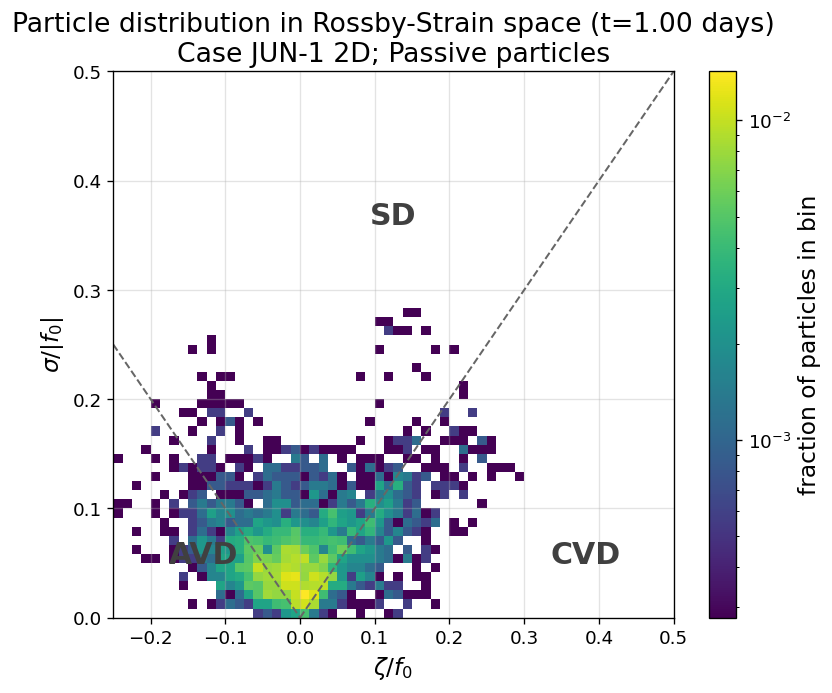

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau6h_k0_obs0008.png


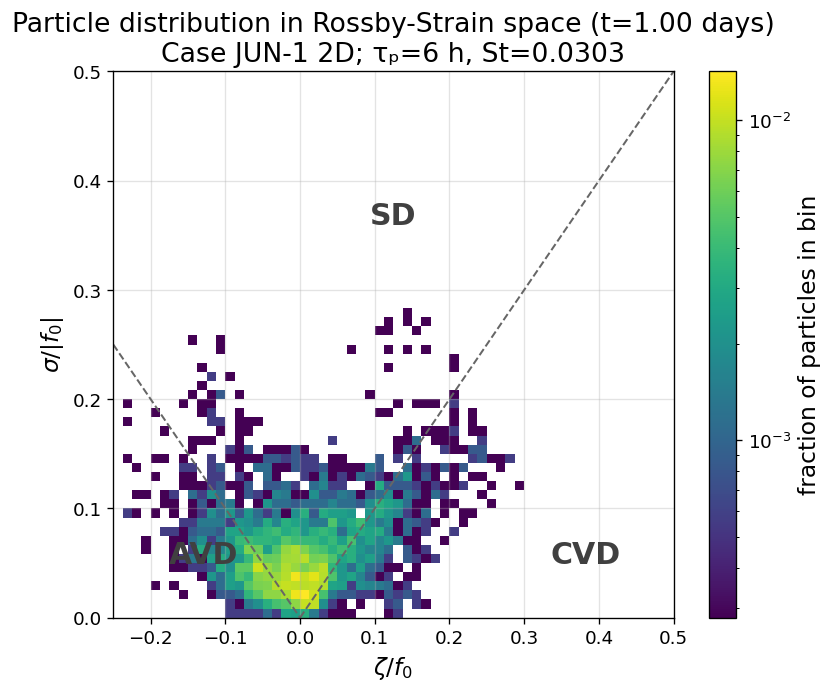

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau12h_k0_obs0008.png


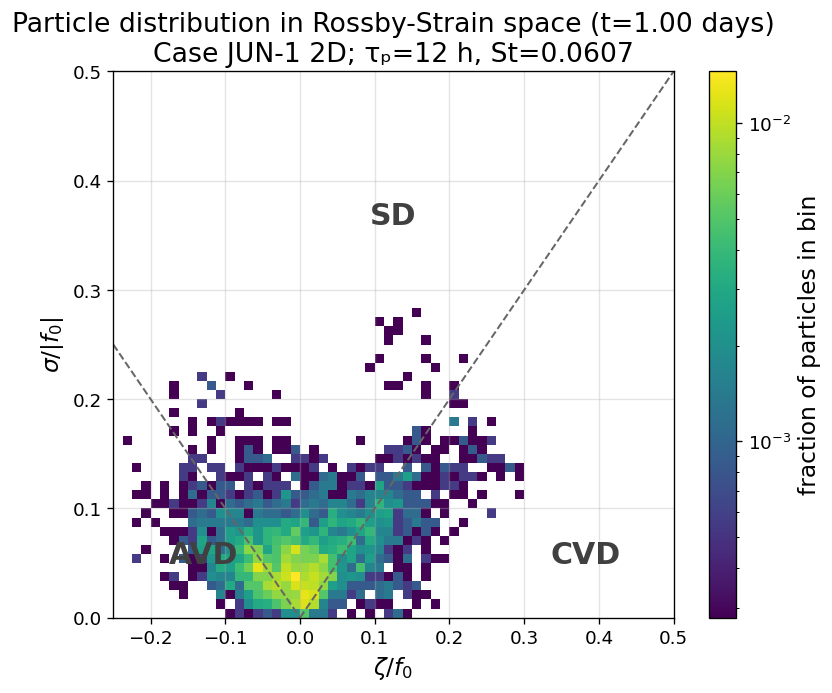

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau1d_k0_obs0008.png


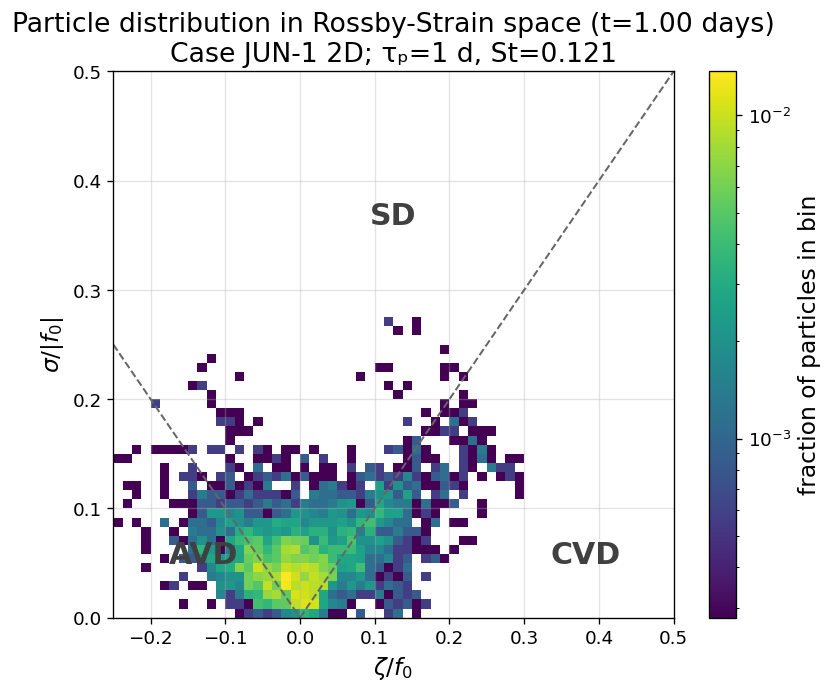

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_strainpassive_k0_obs0024.png


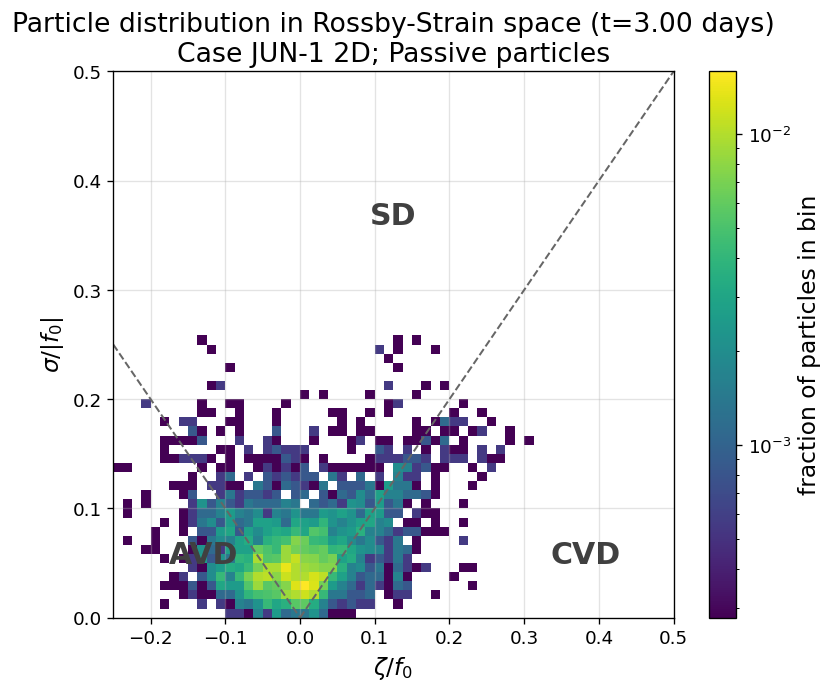

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau6h_k0_obs0024.png


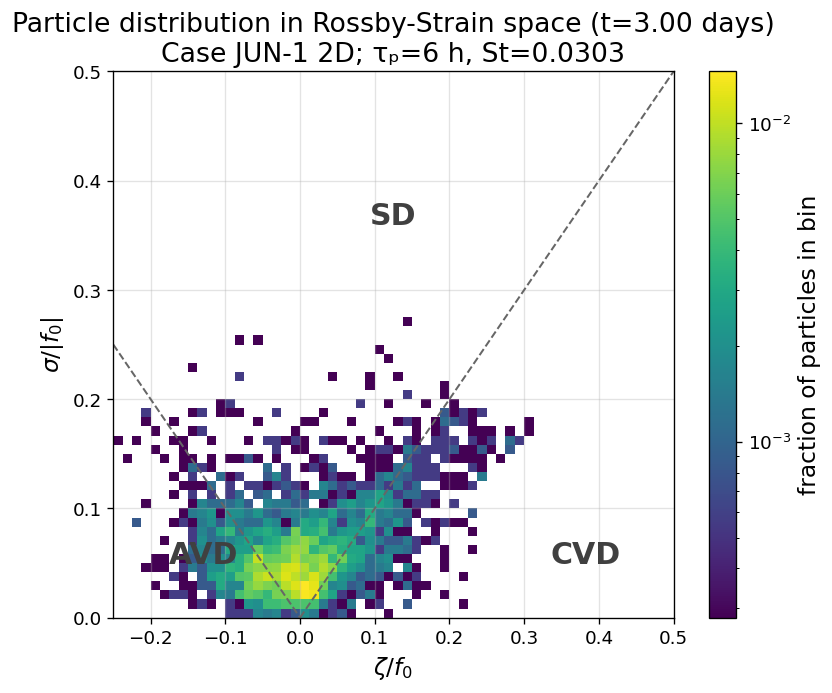

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau12h_k0_obs0024.png


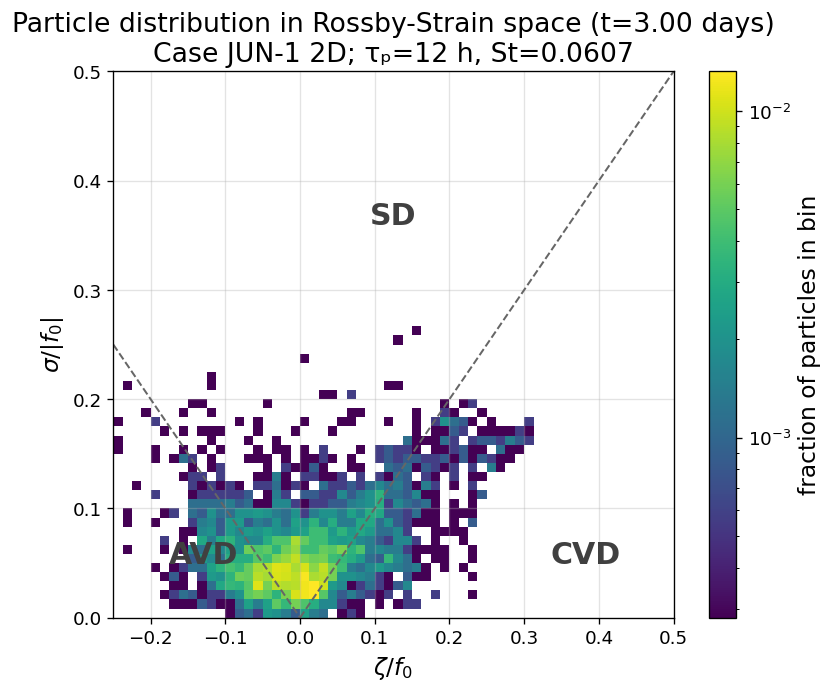

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau1d_k0_obs0024.png


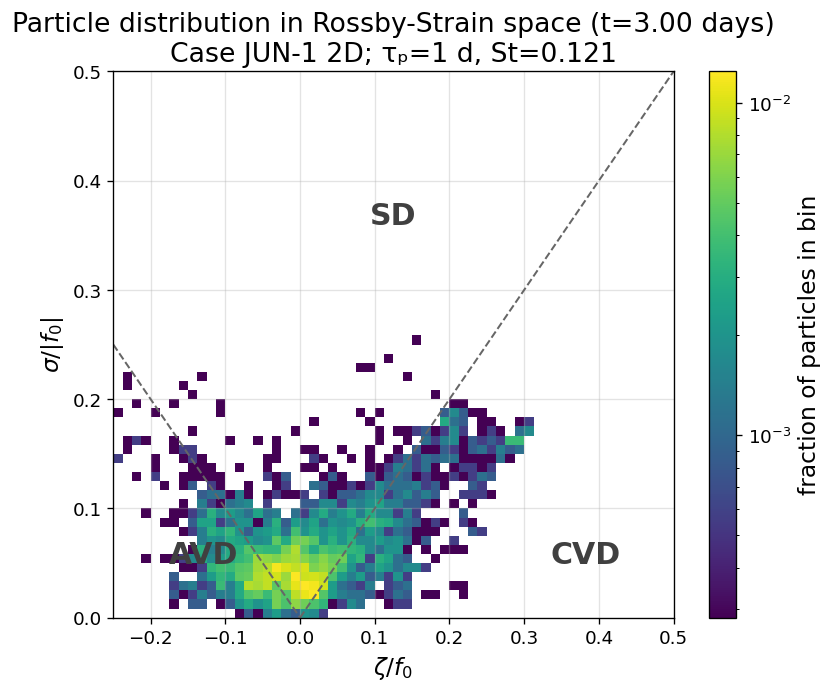

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_strainpassive_k0_obs0040.png


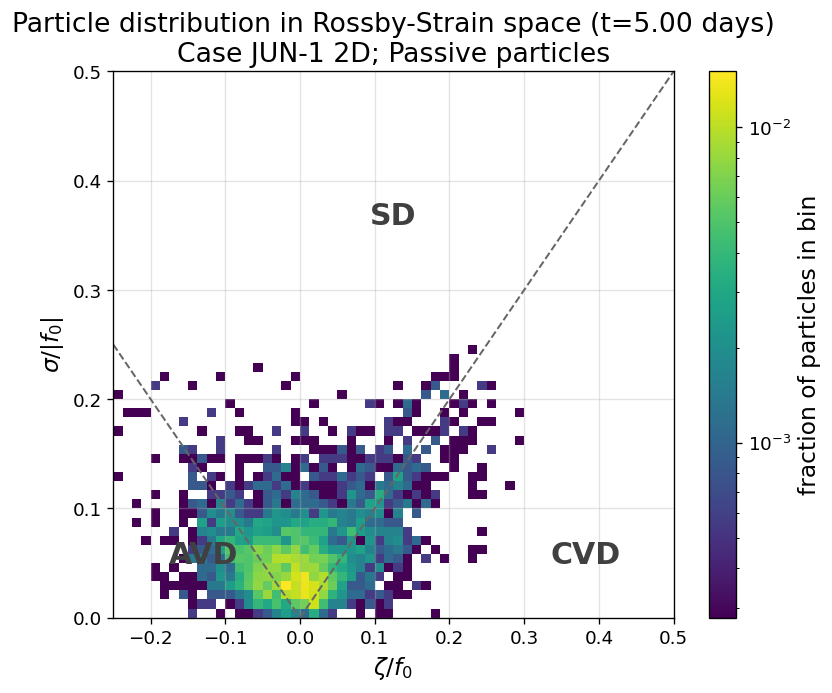

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau6h_k0_obs0040.png


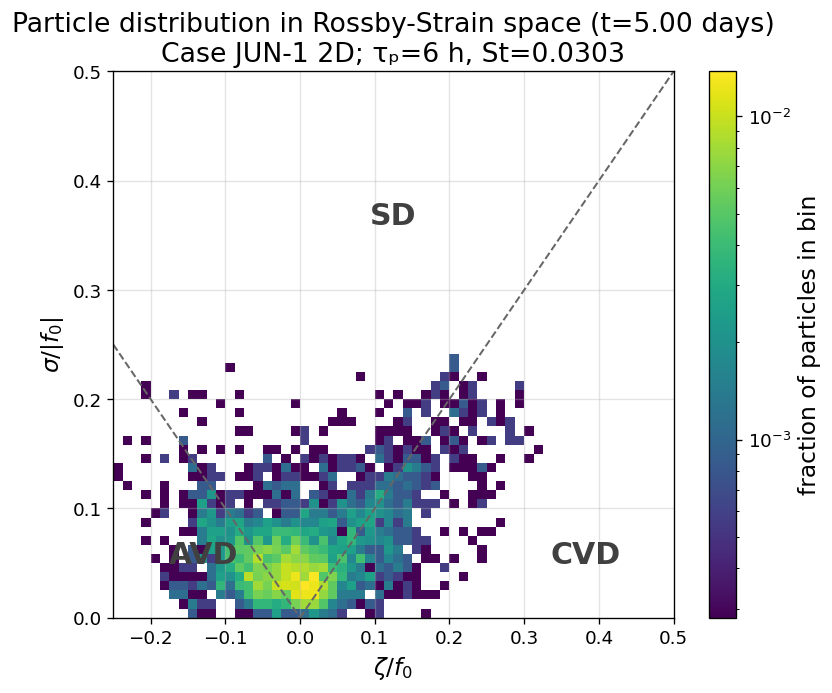

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau12h_k0_obs0040.png


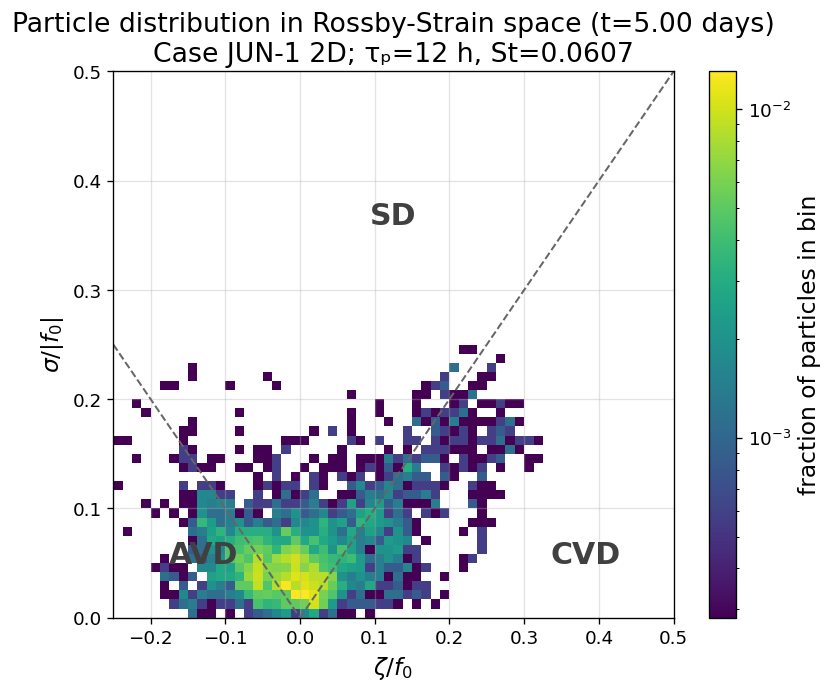

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau1d_k0_obs0040.png


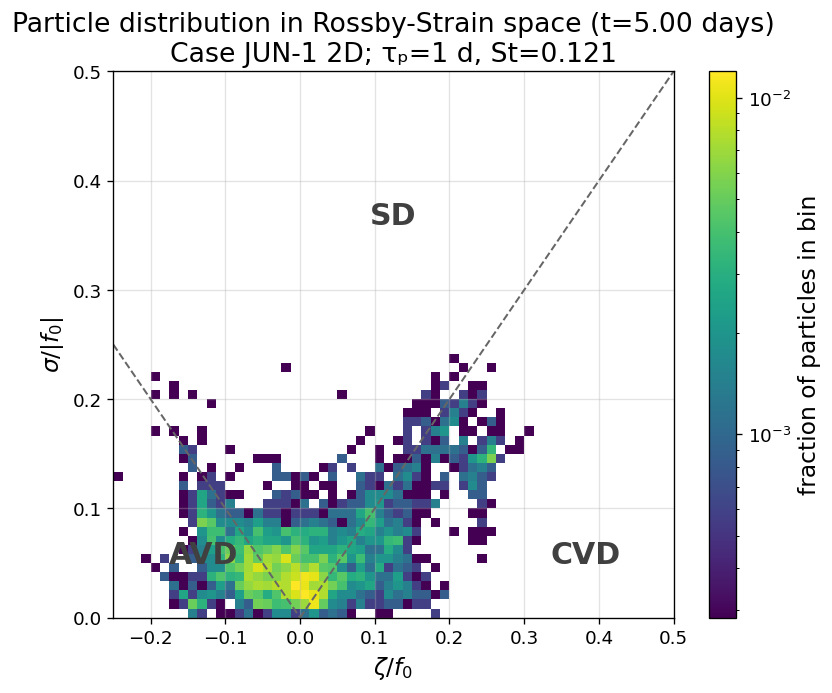

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_strainpassive_k0_obs0064.png


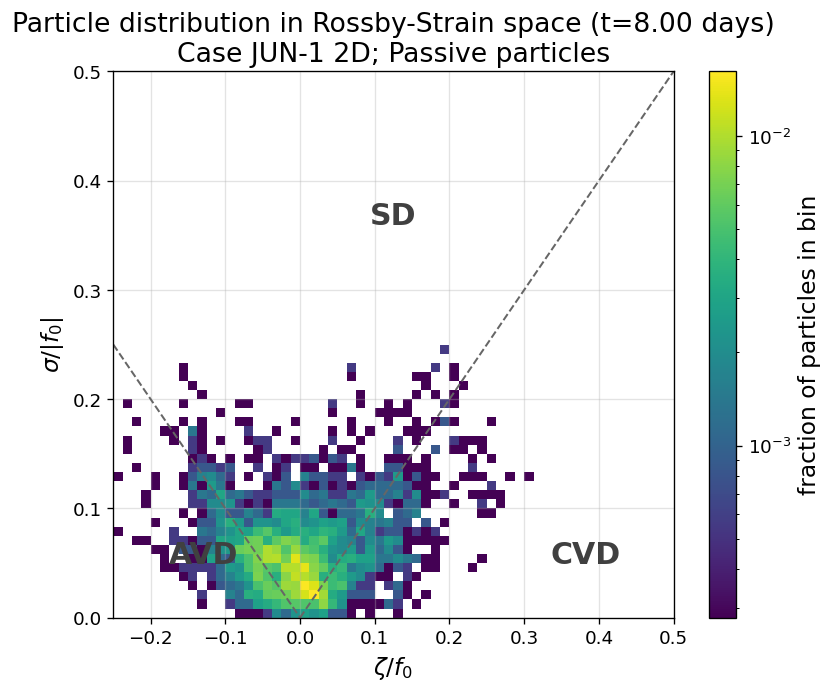

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau6h_k0_obs0064.png


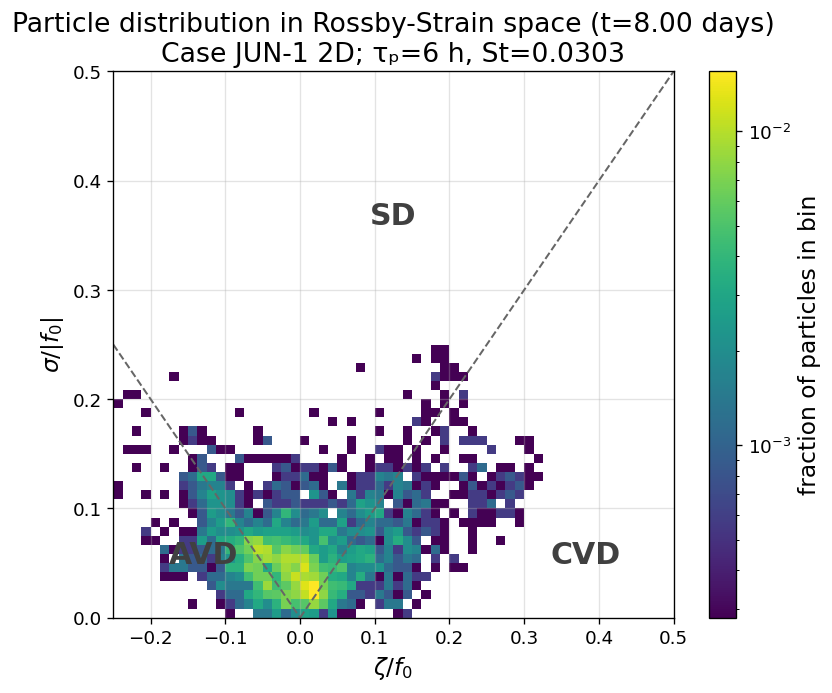

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau12h_k0_obs0064.png


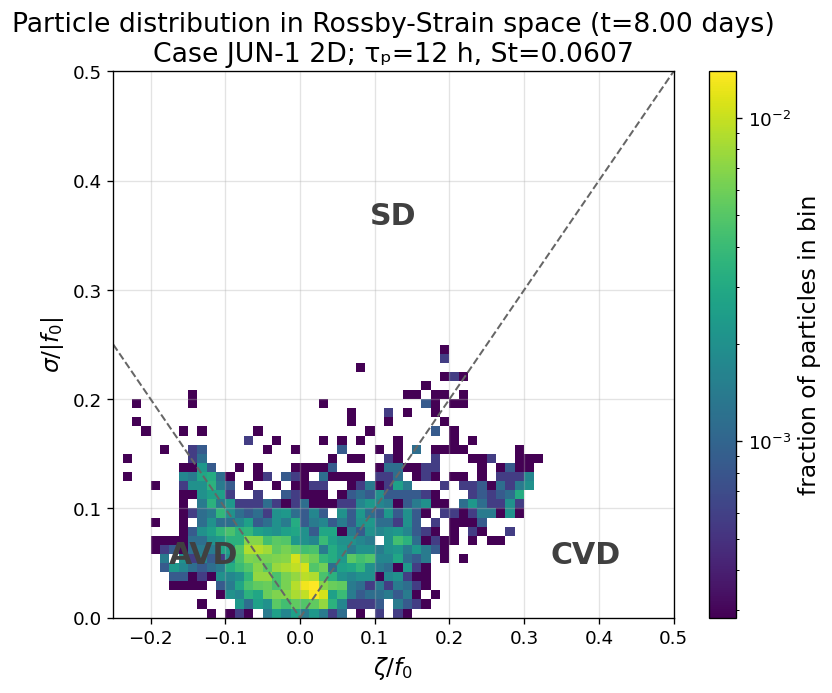

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_ro_strain\conditional_concentration_ro_straintau1d_k0_obs0064.png


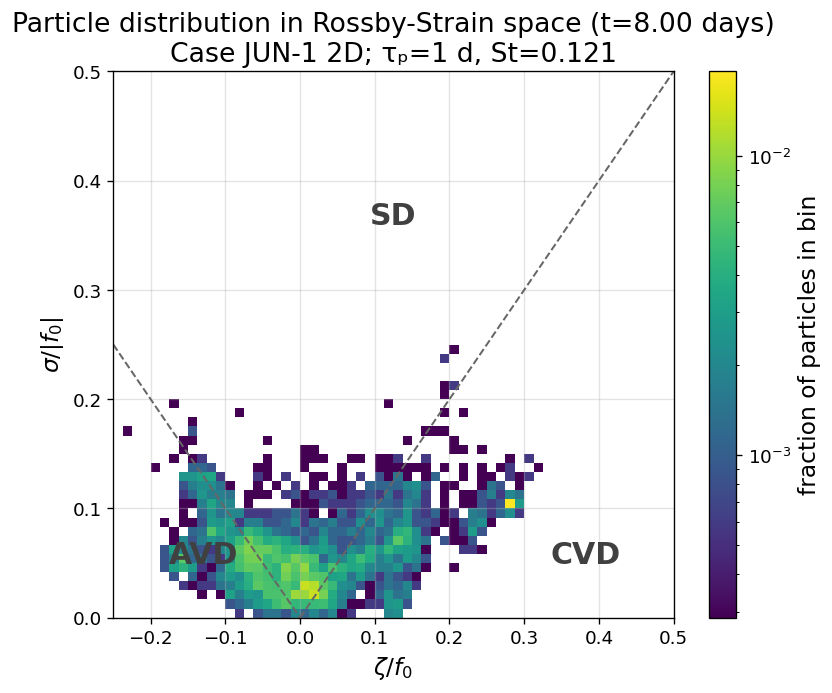

In [7]:
# ============================================================
# CONDITIONAL PARTICLE PDF IN ROSSBY-STRAIN SPACE
# ============================================================

RO_BINS = np.linspace(-0.25, 0.50, 61)
STRAIN_BINS = np.linspace(0.00, 0.50, 61)

if PLOT_CONDITIONAL_PARTICLE_PDF_RO_STR:
    out_dir = COUPLED_FIG_DIR / "conditional_ro_strain_pdf"
    out_dir.mkdir(parents=True, exist_ok=True)

    for obs_idx in snapshot_obs_indices:
        elapsed_days = phelp.get_elapsed_time_days(reference_ds, obs_idx)

        for particle_tag, item in coupled_outputs.items():
            ds_c = item["ds"]
            label = item["label"]

            ro = np.asarray(ds_c["ro_particle"].isel(obs=obs_idx).values, dtype=float)
            strain = np.asarray(ds_c["strain_f_particle"].isel(obs=obs_idx).values, dtype=float)

            pdf, counts = phelp.compute_2d_particle_pdf(
                ro,
                strain,
                RO_BINS,
                STRAIN_BINS,
            )

            fig, ax = plt.subplots(
                figsize=shu.get_figsize("map"),
                facecolor="white",
            )
            ax.set_facecolor("white")

            finite_pdf = pdf[np.isfinite(pdf) & (pdf > 0.0)]
            if finite_pdf.size > 0:
                norm = LogNorm(vmin=np.nanmin(finite_pdf), vmax=np.nanmax(finite_pdf))
            else:
                norm = None

            pcm = ax.pcolormesh(
                RO_BINS,
                STRAIN_BINS,
                pdf,
                shading="auto",
                cmap="viridis",
                norm=norm,
            )

            phelp.draw_ro_strain_regime_guides(
                ax,
                x_min=RO_BINS[0],
                x_max=RO_BINS[-1],
                y_max=STRAIN_BINS[-1],
            )

            ax.set_xlim(RO_BINS[0], RO_BINS[-1])
            ax.set_ylim(STRAIN_BINS[0], STRAIN_BINS[-1])

            ax.set_xlabel(r"$\zeta/f_0$")
            ax.set_ylabel(r"$\sigma/|f_0|$")

            ax.set_title(
                f"Particle distribution in Rossby-Strain space (t={elapsed_days:.2f} days)\n"
                f"{RUN_TITLE_INFO}; {label}"
            )

            cbar = fig.colorbar(pcm, ax=ax)
            cbar.set_label(r"fraction of particles in bin")

            fig.tight_layout()

            if SAVE_FIGURES:
                out_dir = COUPLED_FIG_DIR / "conditional_concentration_ro_strain"
                out_dir.mkdir(parents=True, exist_ok=True)
                shu.savefig_if_needed(fig, f"conditional_concentration_ro_strain{particle_tag}_{flow_level_tag}_obs{obs_idx:04d}", save=True, out_dir=out_dir)

            plt.show()

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_passive_k0_obs0008.png


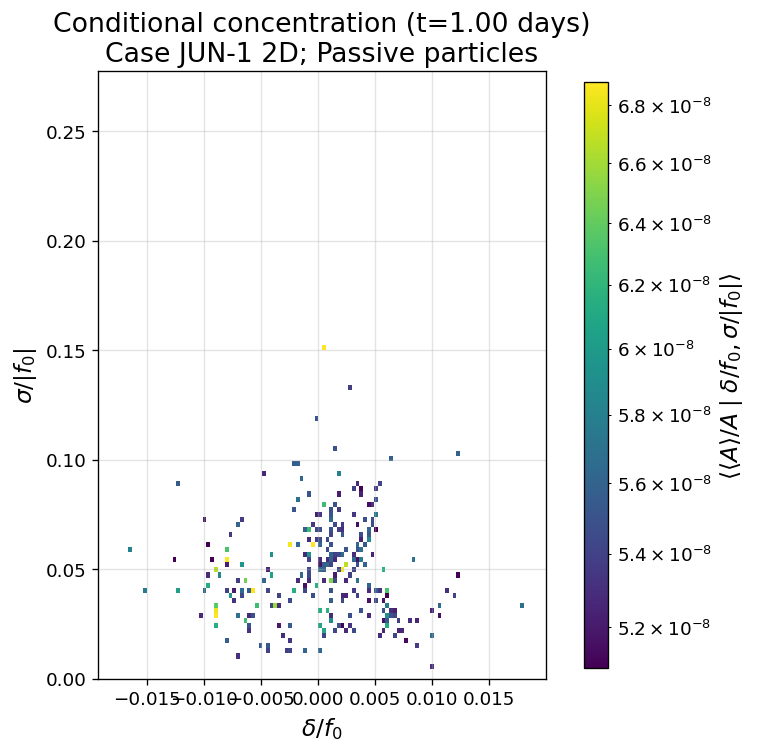

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau6h_k0_obs0008.png


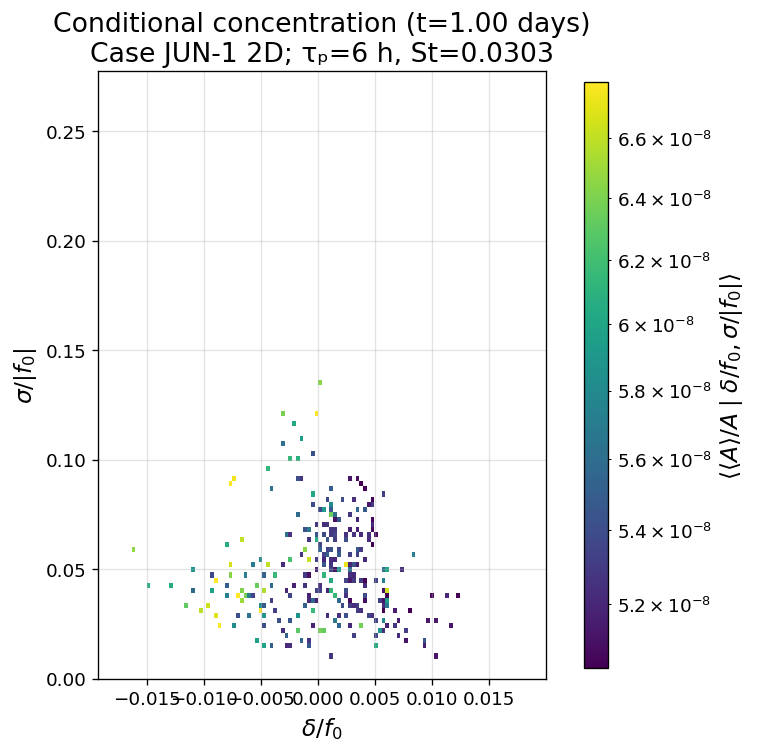

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau12h_k0_obs0008.png


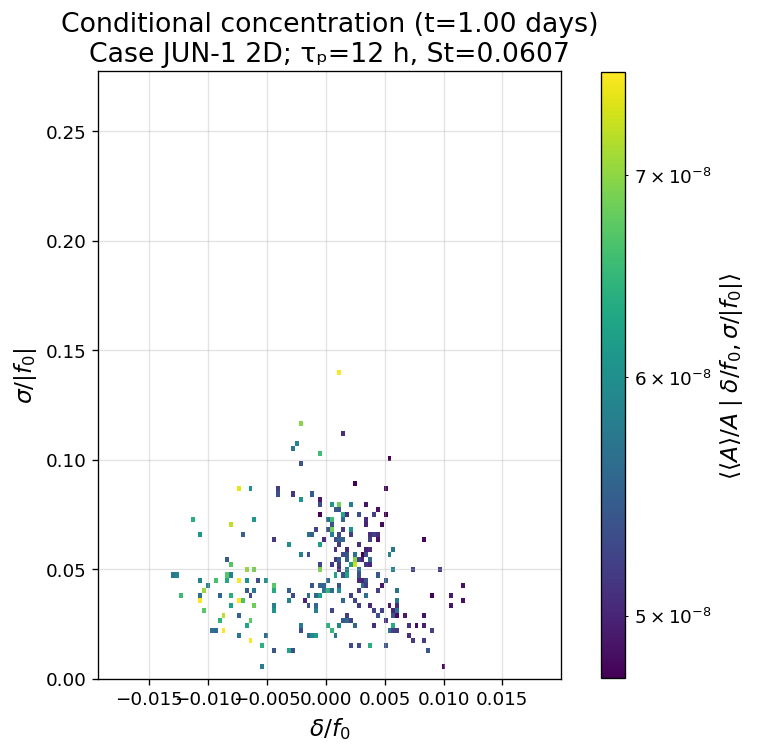

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau1d_k0_obs0008.png


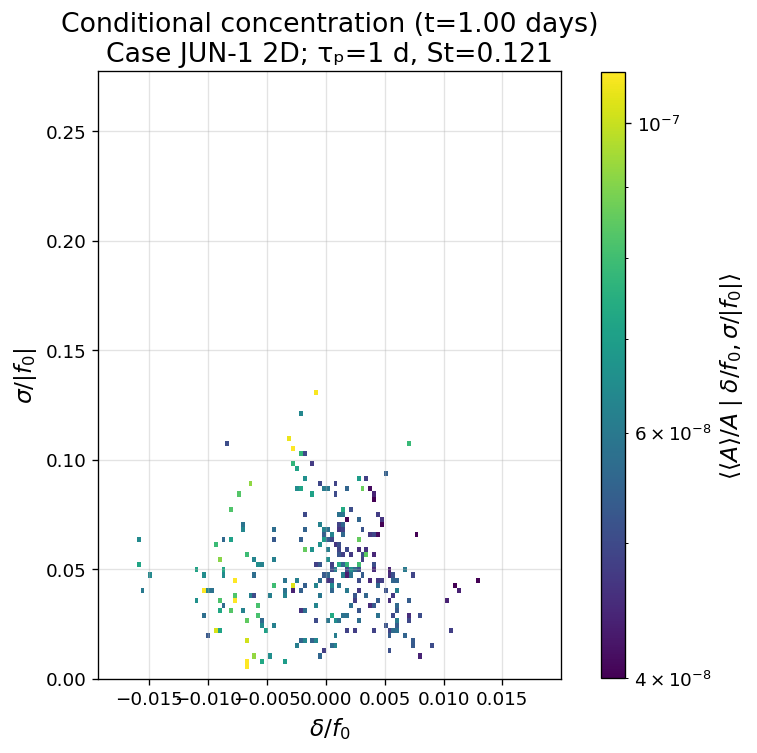

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_passive_k0_obs0024.png


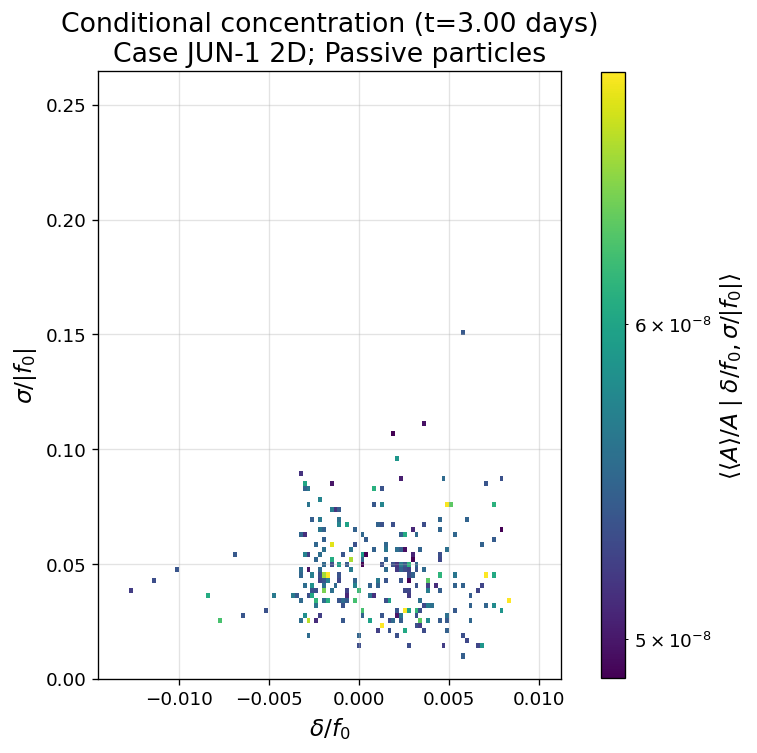

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau6h_k0_obs0024.png


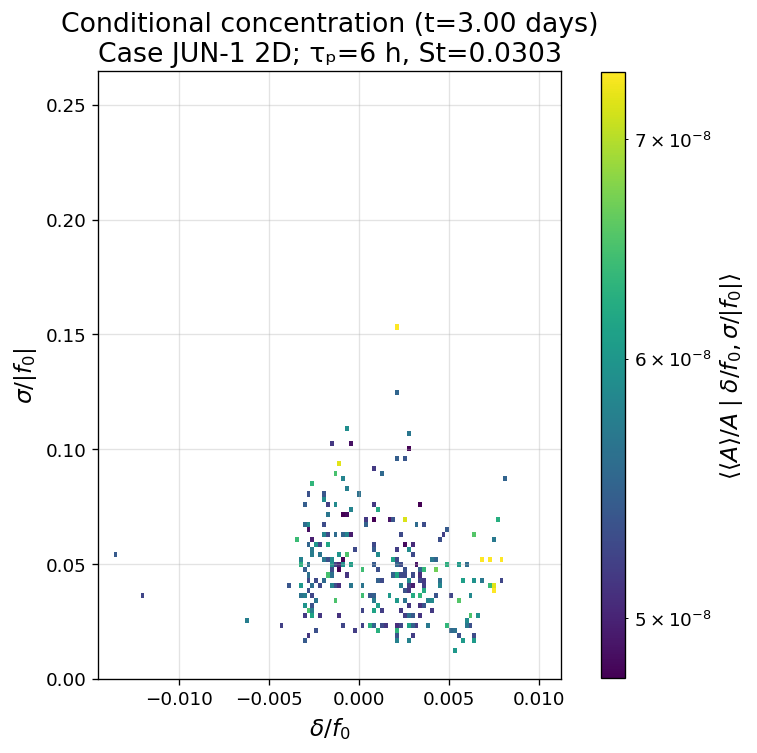

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau12h_k0_obs0024.png


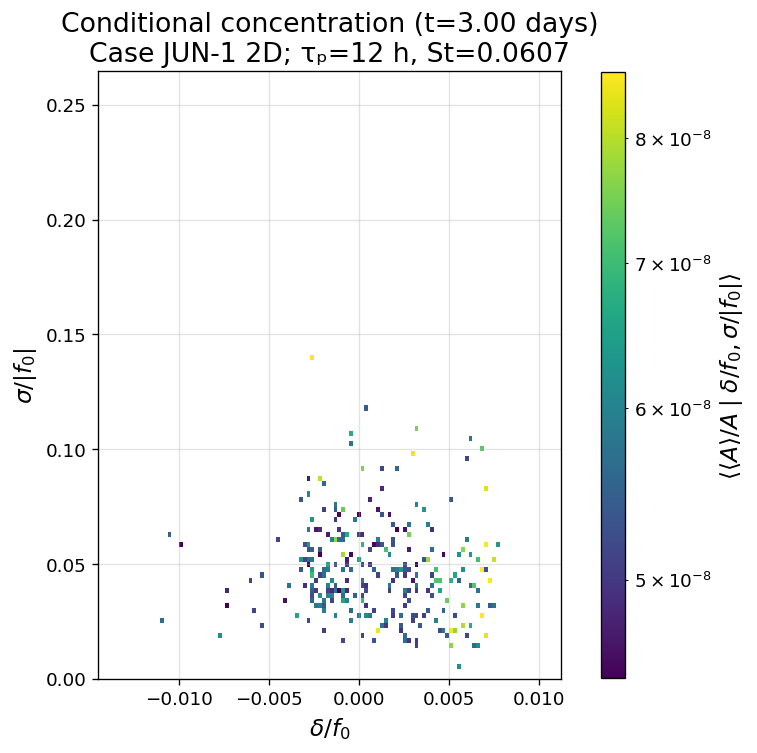

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau1d_k0_obs0024.png


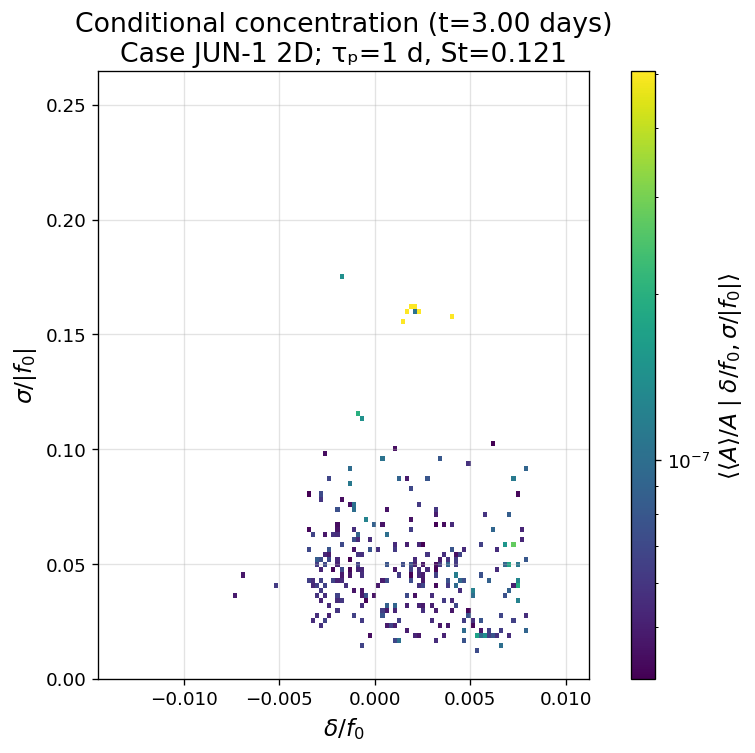

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_passive_k0_obs0040.png


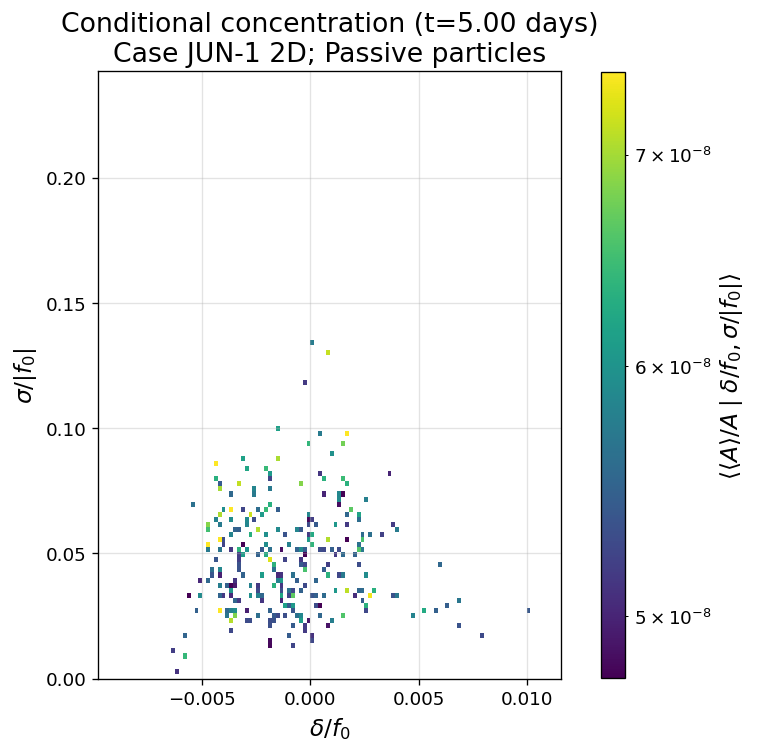

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau6h_k0_obs0040.png


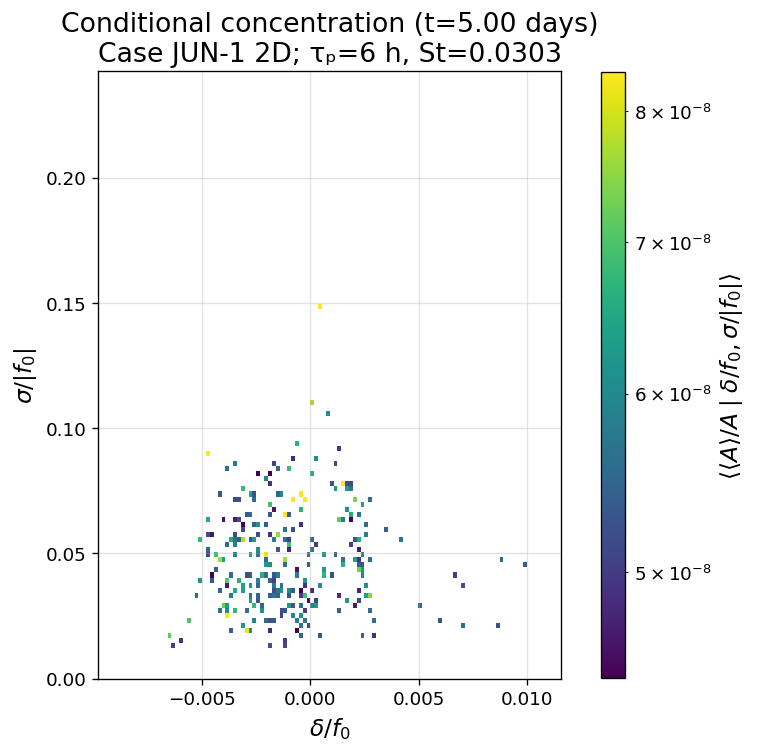

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau12h_k0_obs0040.png


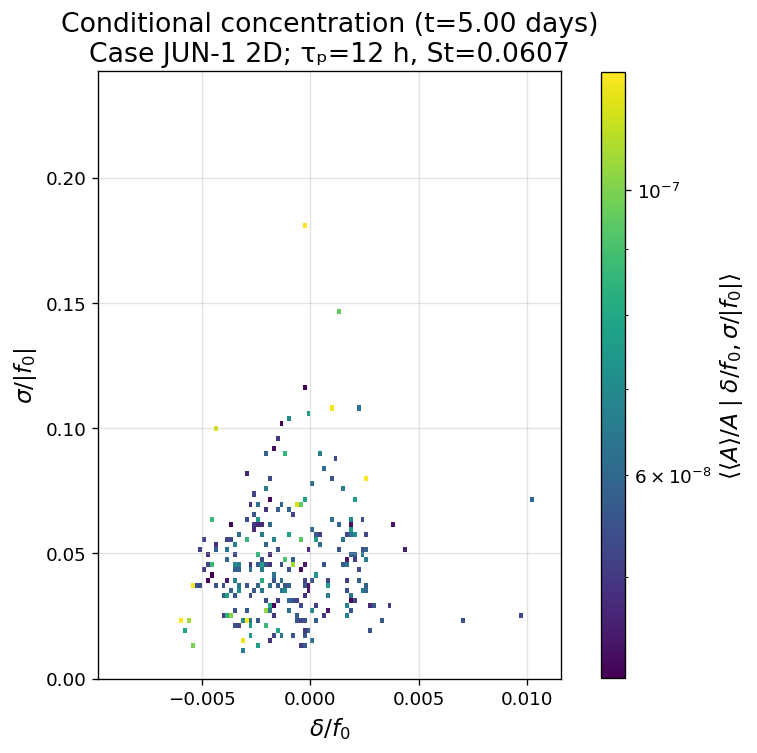

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau1d_k0_obs0040.png


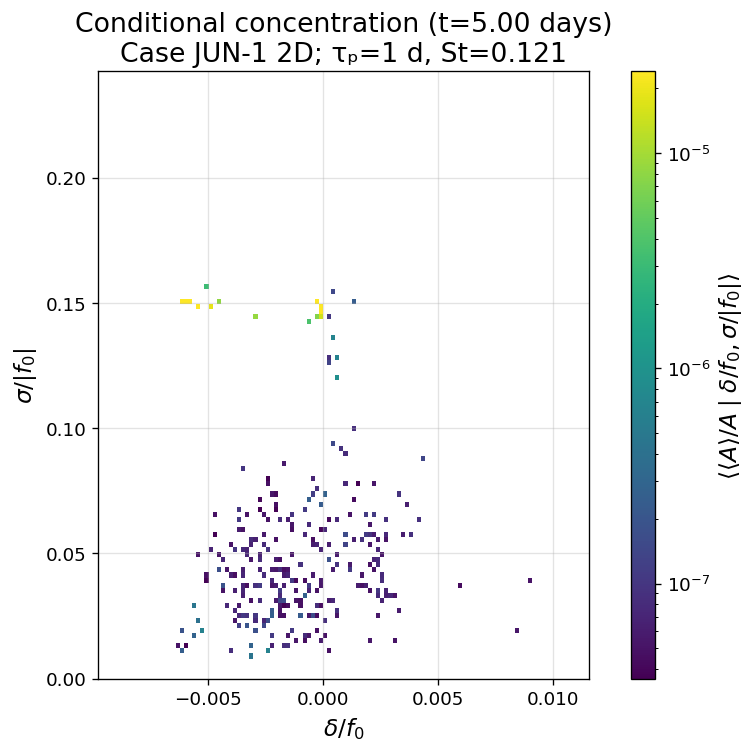

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_passive_k0_obs0064.png


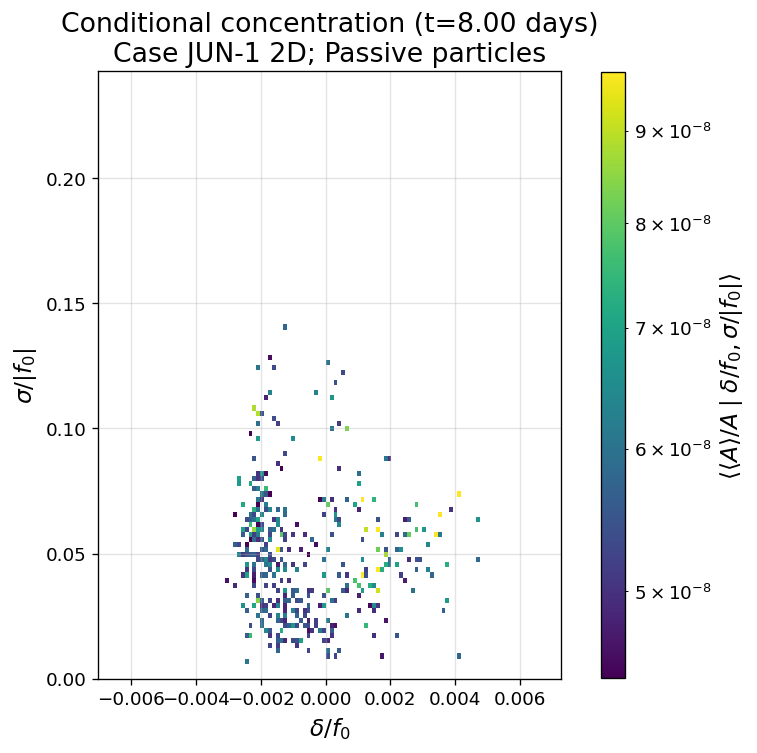

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau6h_k0_obs0064.png


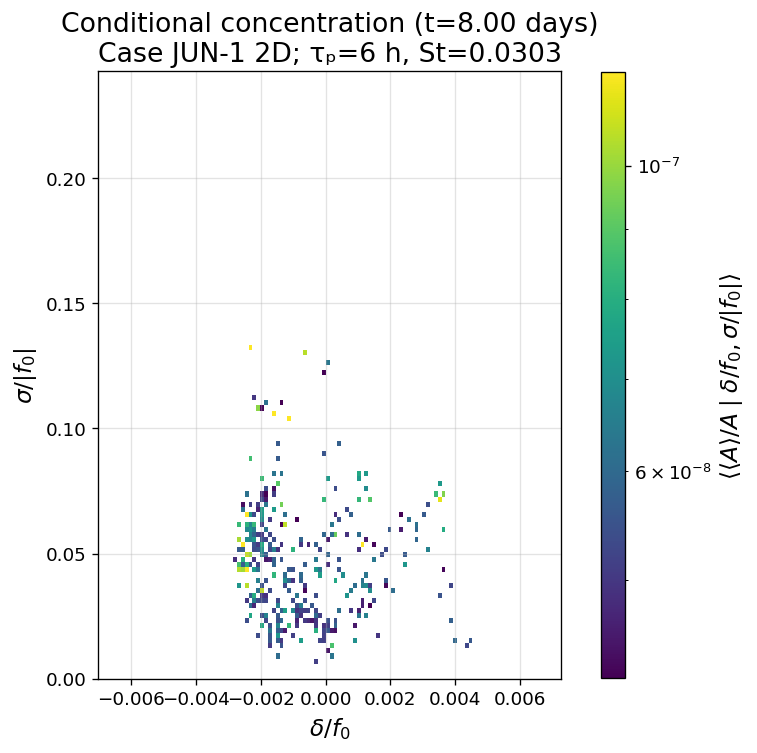

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau12h_k0_obs0064.png


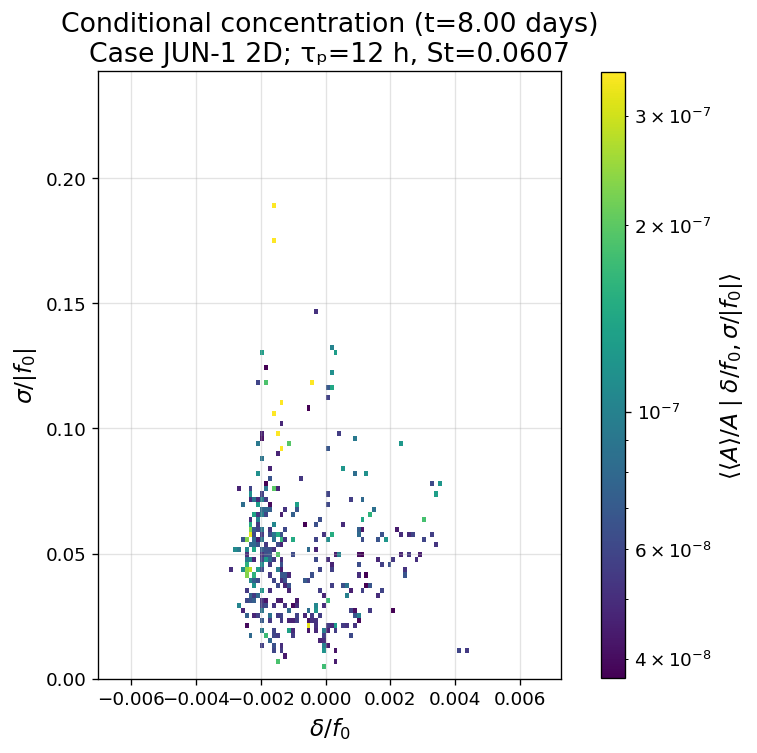

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\conditional_concentration_div_strain\conditional_concentration_div_strain_tau1d_k0_obs0064.png


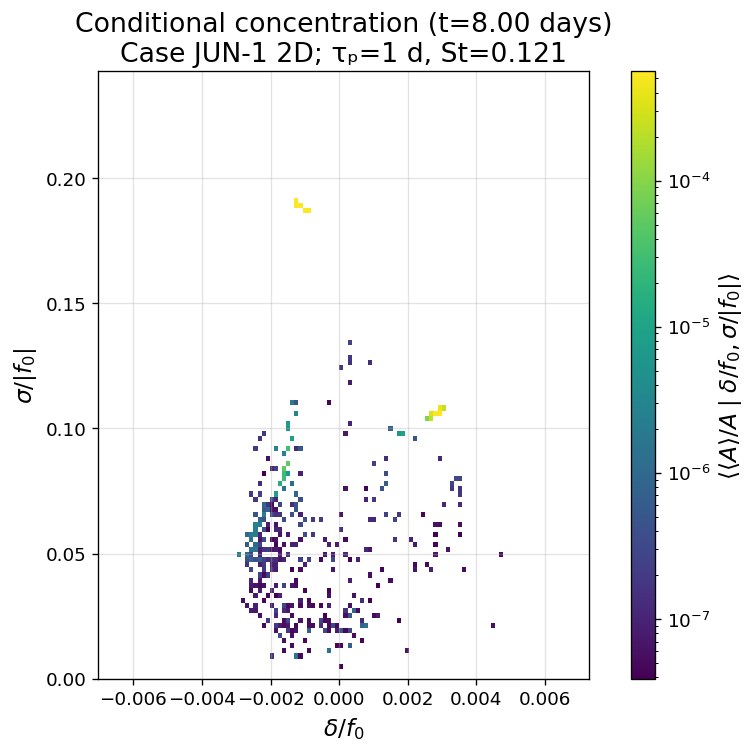

In [8]:
# ============================================================
# 10. CONDITIONAL CONCENTRATION IN DIVERGENCE–STRAIN SPACE
# ============================================================

if PLOT_CONDITIONAL_CONCENTRATION_DIV_STRAIN:
    for obs_idx in snapshot_obs_indices:
        flow_snapshot = ds_flow.sel(obs=obs_idx)
        x_edges, y_edges = phelp.conditional_edges(
            flow_snapshot,
            "div_f",
            "strain_f",
            nbins=CONDITIONAL_NBINS,
            percentiles=CONDITIONAL_PERCENTILES,
            y_nonnegative=True,
        )

        for particle_tag, item in coupled_outputs.items():
            ds_c = item["ds"]
            label = item["label"]

            div_p = np.asarray(ds_c["div_f_particle"].sel(obs=obs_idx).values, dtype=float)
            strain_p = np.asarray(ds_c["strain_f_particle"].sel(obs=obs_idx).values, dtype=float)
            conc = np.asarray(ds_c[CONCENTRATION_VARIABLE].sel(obs=obs_idx).values, dtype=float)

            mask = np.isfinite(div_p) & np.isfinite(strain_p) & np.isfinite(conc) & (conc > 0.0)
            cond_mean, cond_count = phelp.conditioned_mean_2d(
                div_p[mask],
                strain_p[mask],
                conc[mask],
                x_edges,
                y_edges,
                conditioned_mean_func=shu.conditioned_mean_2d,
                min_count=CONDITIONAL_MIN_PARTICLES_PER_BIN,
            )

            valid = cond_mean[np.isfinite(cond_mean)]
            if valid.size:
                vmin, vmax = np.nanpercentile(valid, CONCENTRATION_COLOR_PERCENTILES)
            else:
                vmin, vmax = 0.0, 1.0
            if not np.isfinite(vmin):
                vmin = 0.0
            if not np.isfinite(vmax) or vmax <= vmin:
                vmax = vmin + 1.0

            t_days = phelp.snapshot_elapsed_days(obs_idx, ds_c)
            fig, ax = phelp.plot_conditional_panel(
                cond_mean,
                x_edges,
                y_edges,
                title=f"Conditional concentration (t={t_days:.2f} days)\n{RUN_TITLE_INFO}; {label}",
                xlabel=r"$\delta/f_0$",
                ylabel=r"$\sigma/|f_0|$",
                cbar_label=r"$\left\langle \langle A\rangle/A \mid \delta/f_0,\sigma/|f_0|\right\rangle$",
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
                log_color=CONCENTRATION_LOG_COLOR,
                add_ro_regimes=False,
                plot_utils=shu,
            )

            if SAVE_FIGURES:
                out_dir = COUPLED_FIG_DIR / "conditional_concentration_div_strain"
                out_dir.mkdir(parents=True, exist_ok=True)
                shu.savefig_if_needed(fig, f"conditional_concentration_div_strain_{particle_tag}_{flow_level_tag}_obs{obs_idx:04d}", save=True, out_dir=out_dir)

            plt.show()


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_passive_k0_obs0008.png


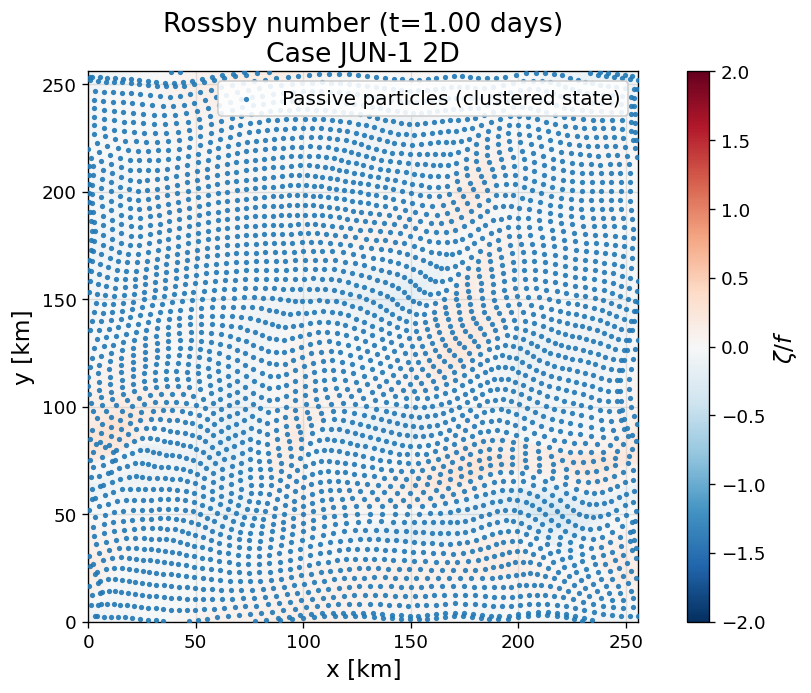

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau6h_k0_obs0008.png


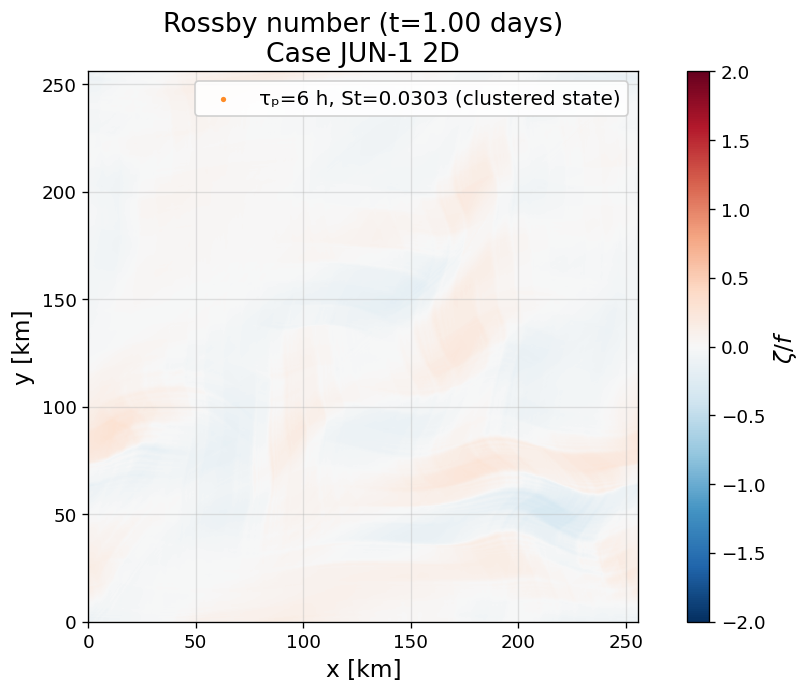

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau12h_k0_obs0008.png


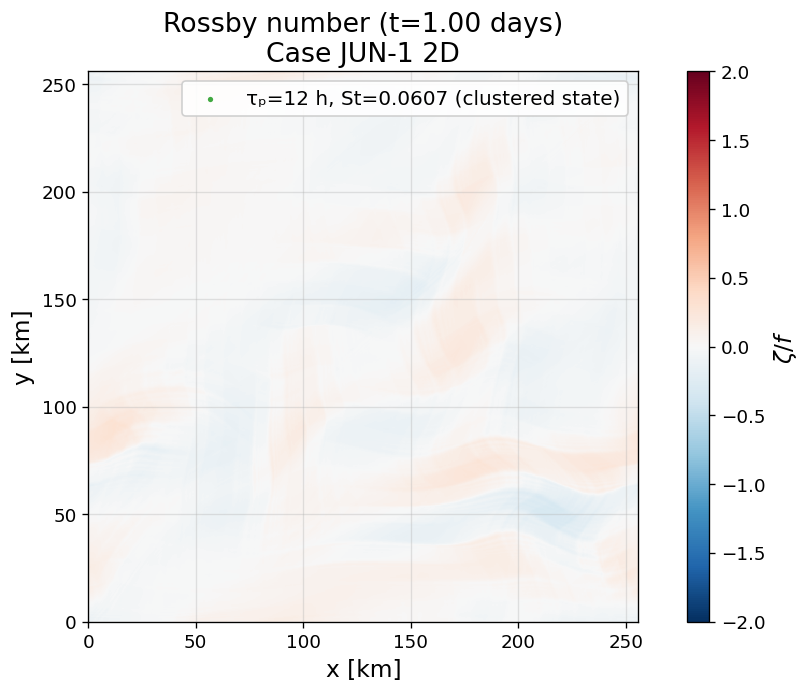

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau1d_k0_obs0008.png


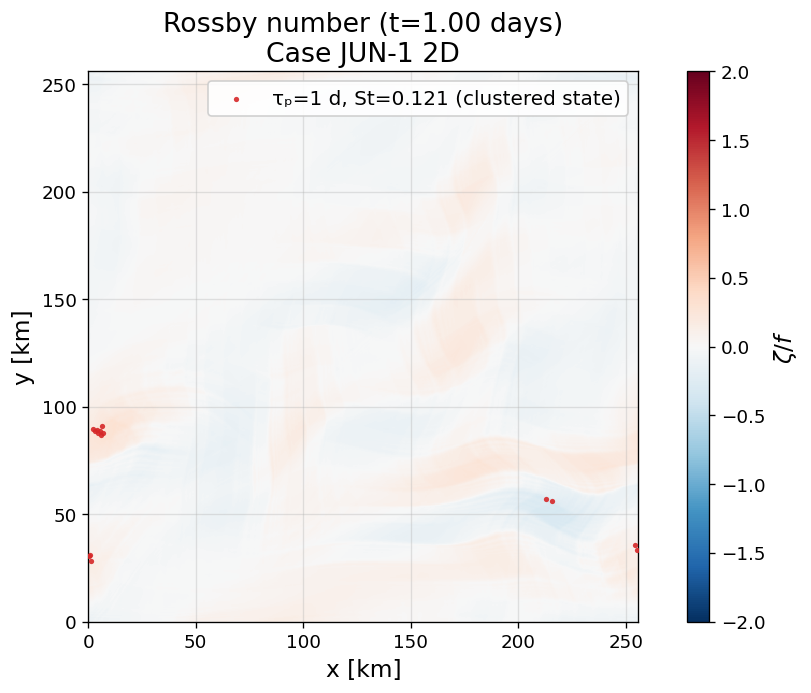

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_passive_k0_obs0024.png


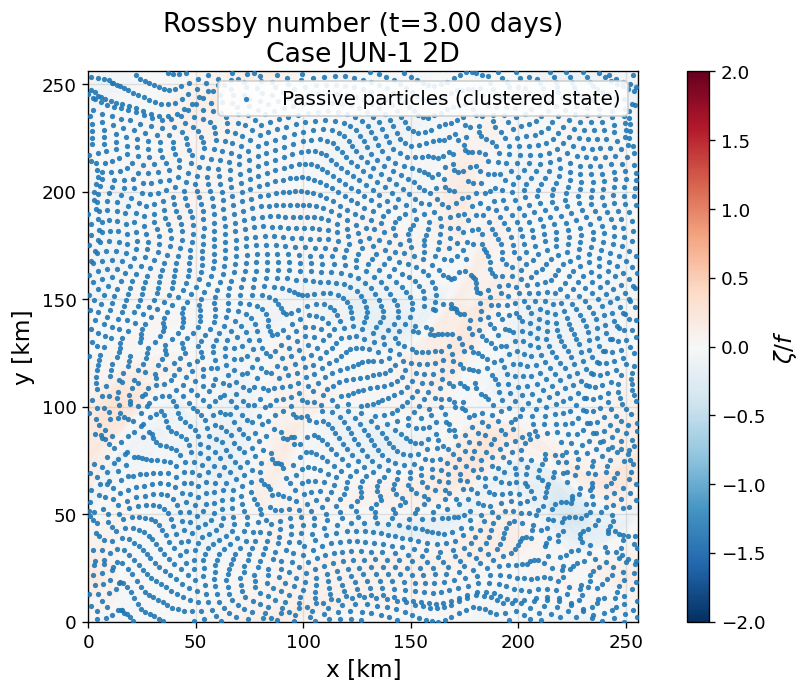

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau6h_k0_obs0024.png


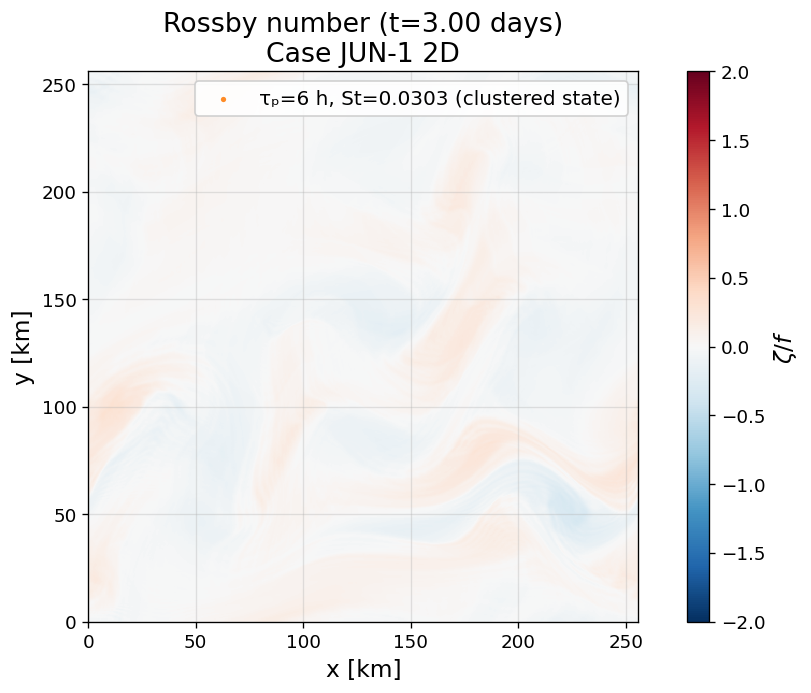

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau12h_k0_obs0024.png


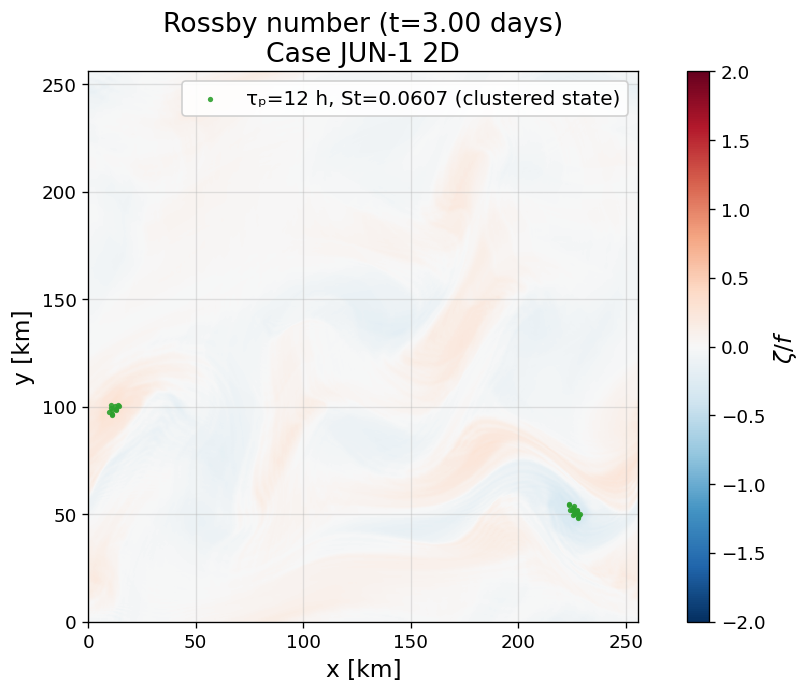

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau1d_k0_obs0024.png


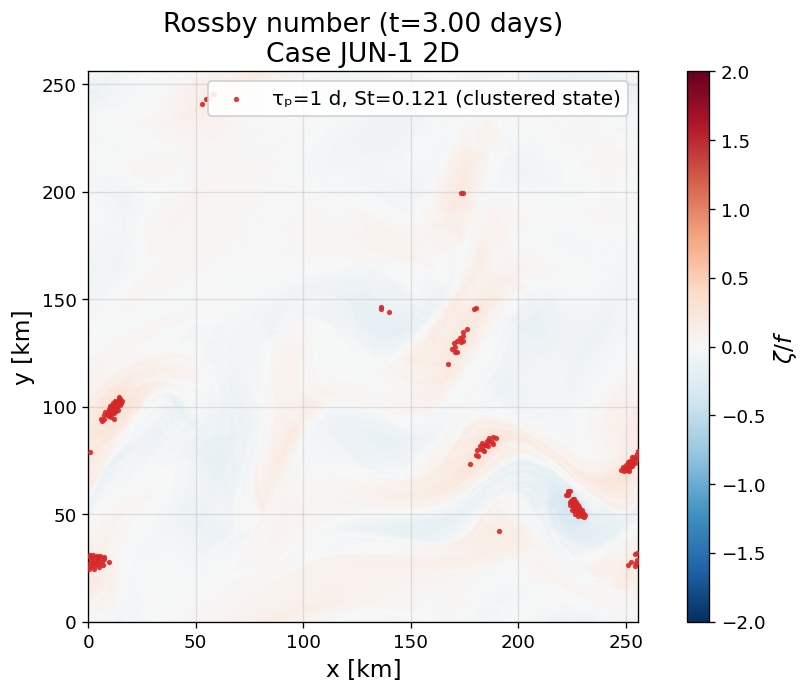

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_passive_k0_obs0040.png


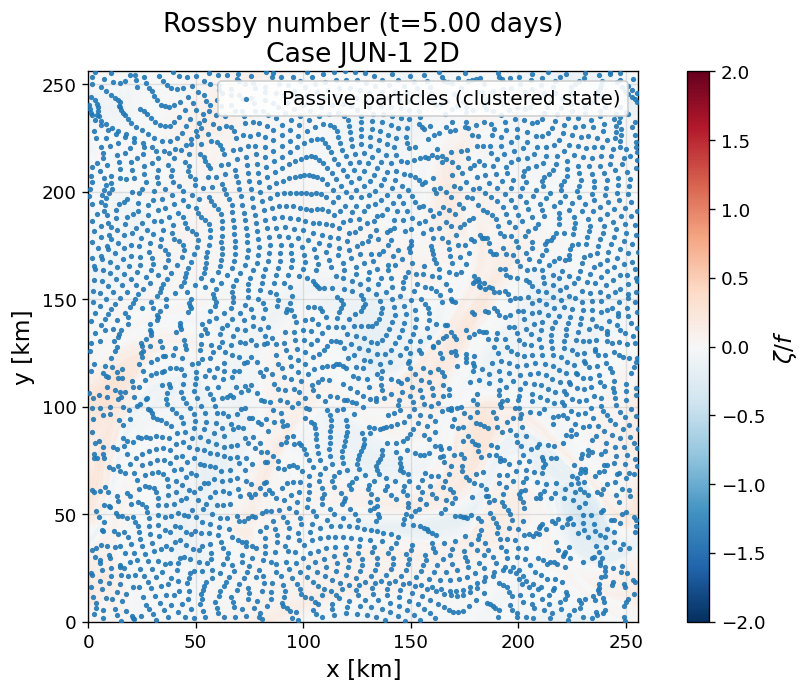

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau6h_k0_obs0040.png


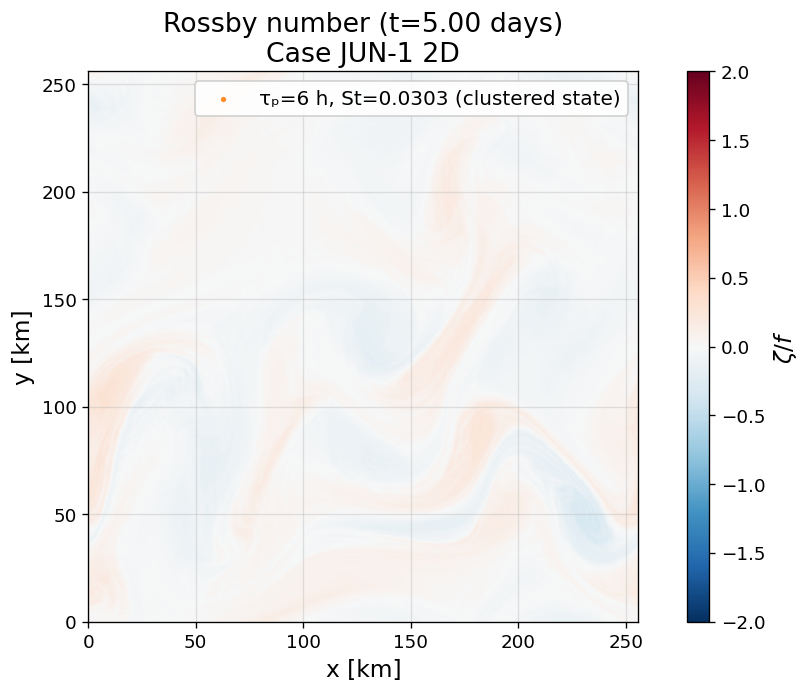

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau12h_k0_obs0040.png


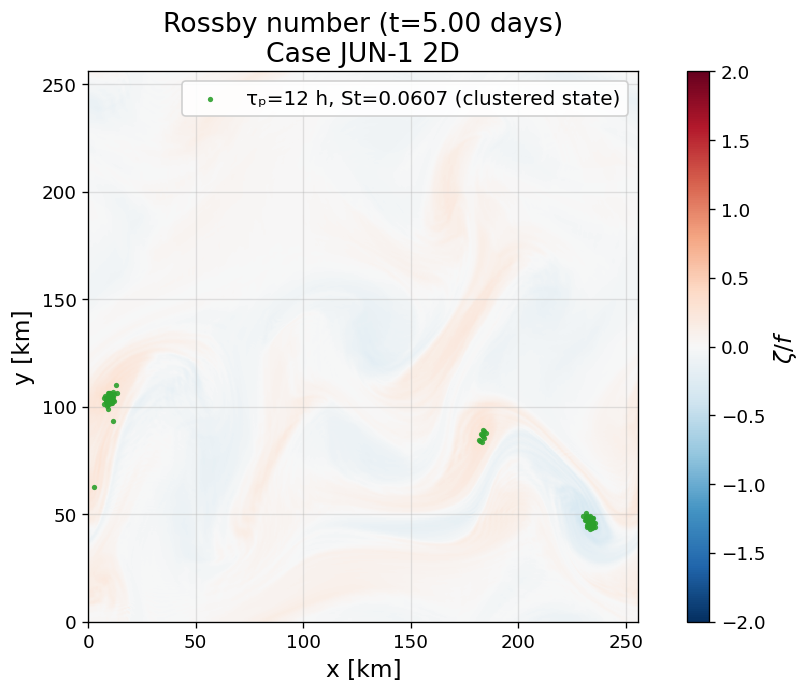

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau1d_k0_obs0040.png


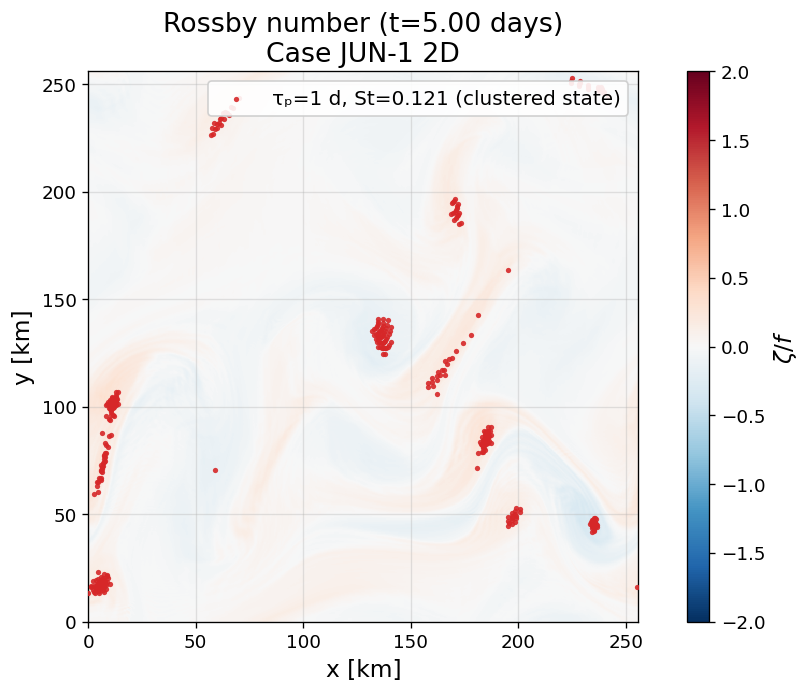

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_passive_k0_obs0064.png


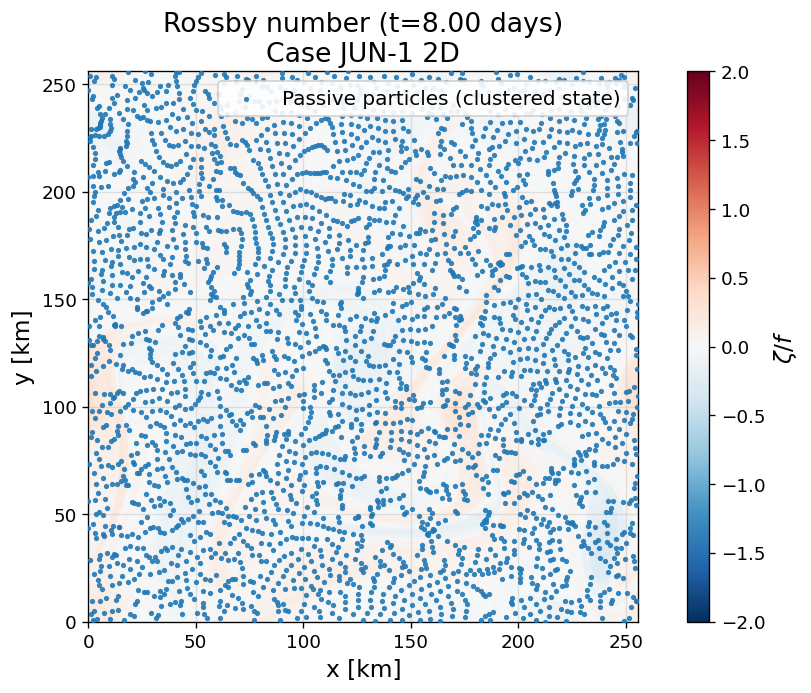

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau6h_k0_obs0064.png


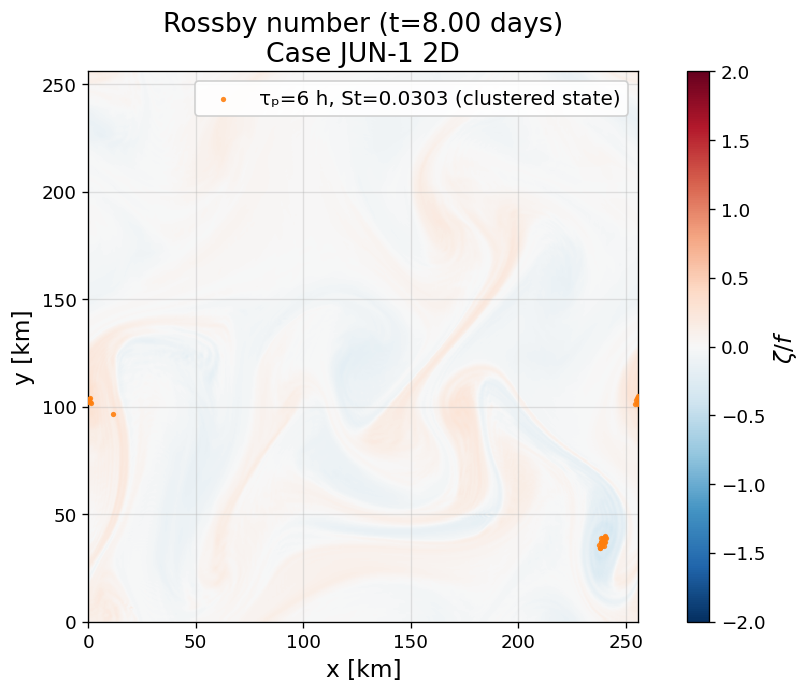

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau12h_k0_obs0064.png


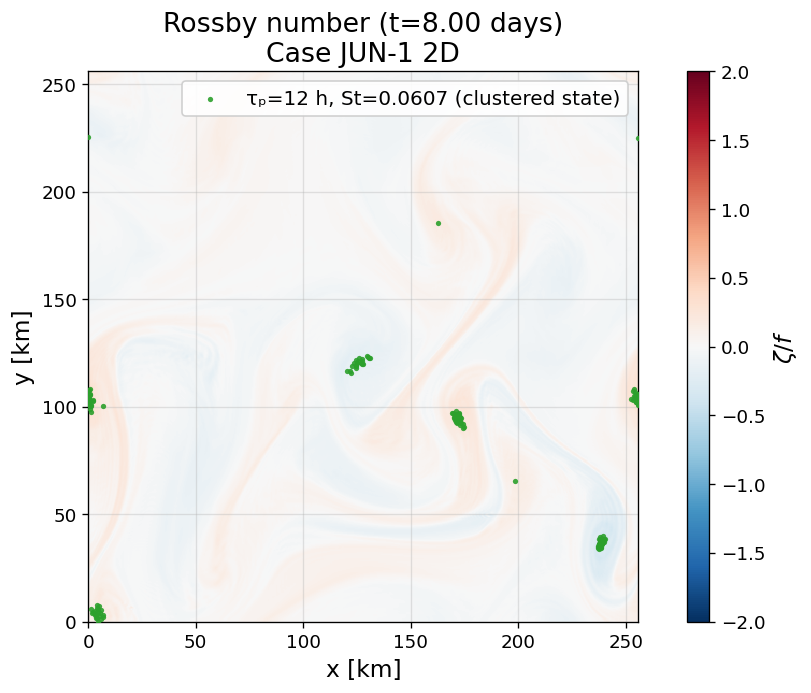

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\rossby_overlays\ro_tau1d_k0_obs0064.png


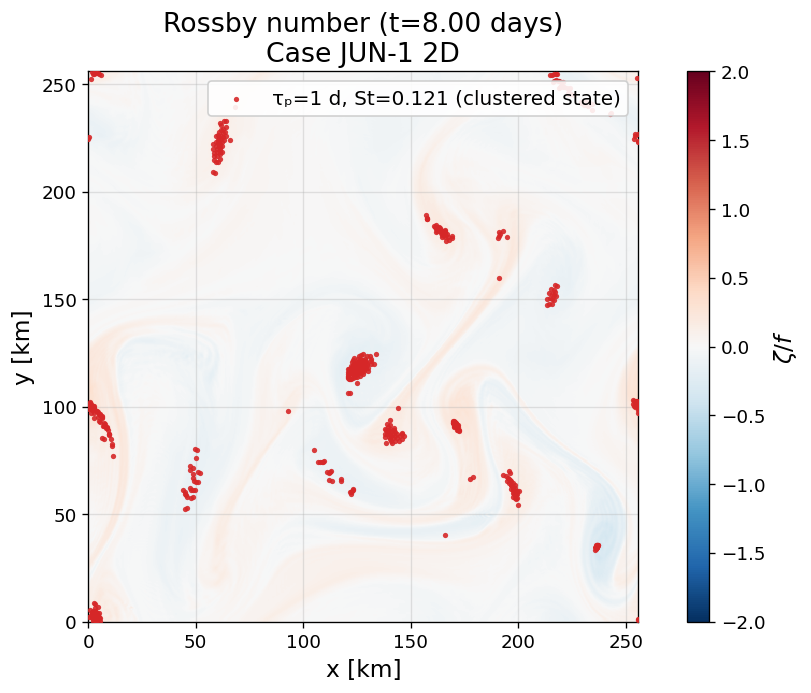

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_passive_k0_obs0008.png


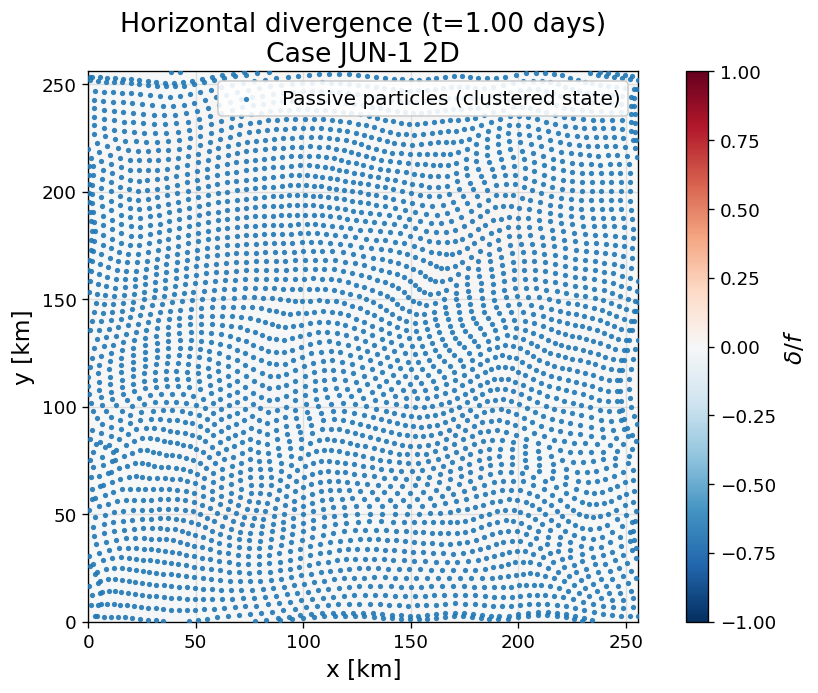

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau6h_k0_obs0008.png


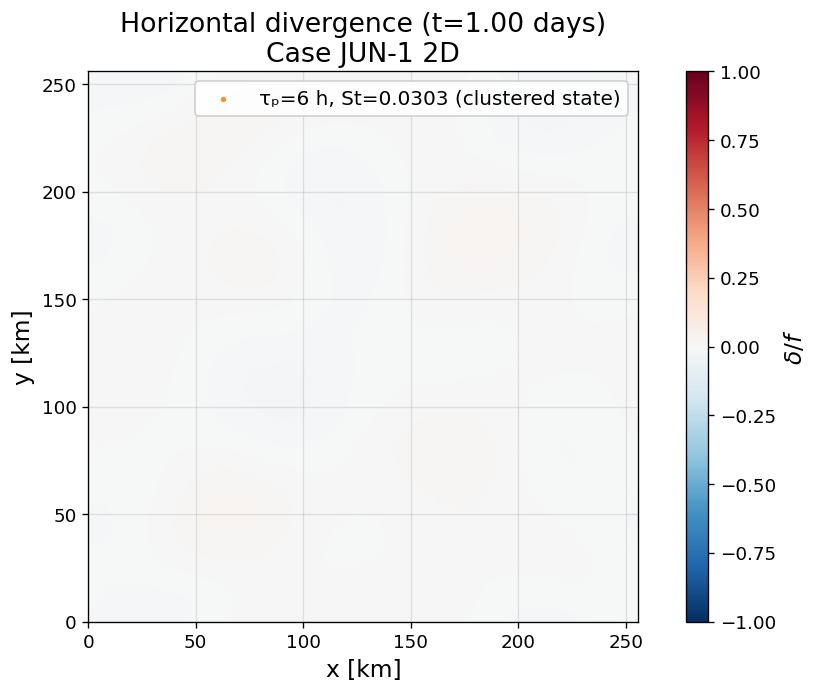

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau12h_k0_obs0008.png


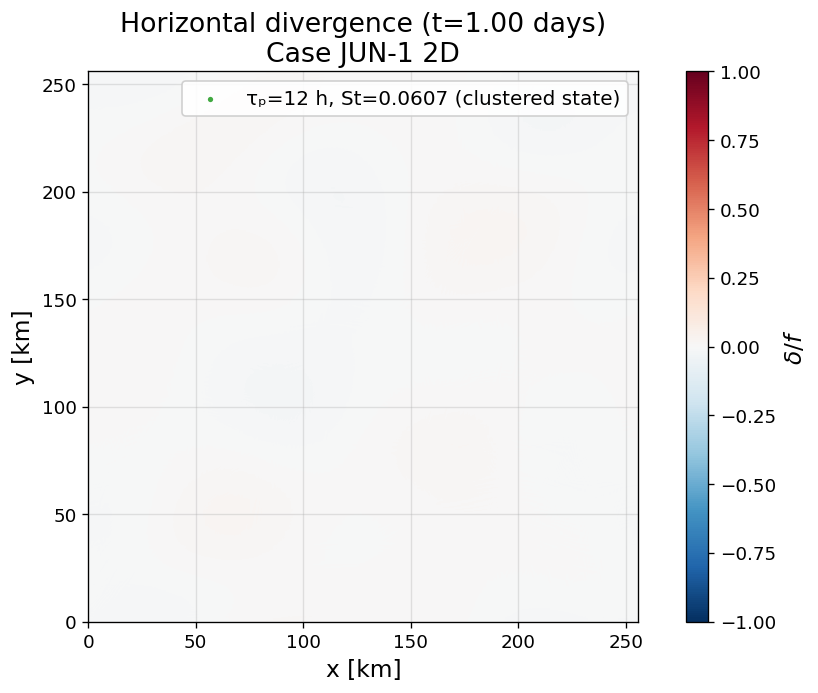

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau1d_k0_obs0008.png


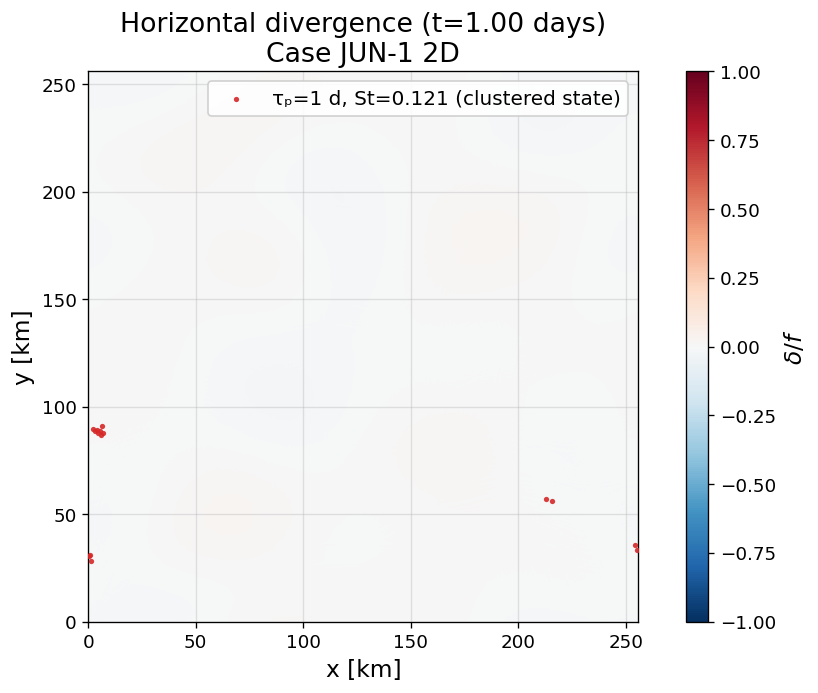

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_passive_k0_obs0024.png


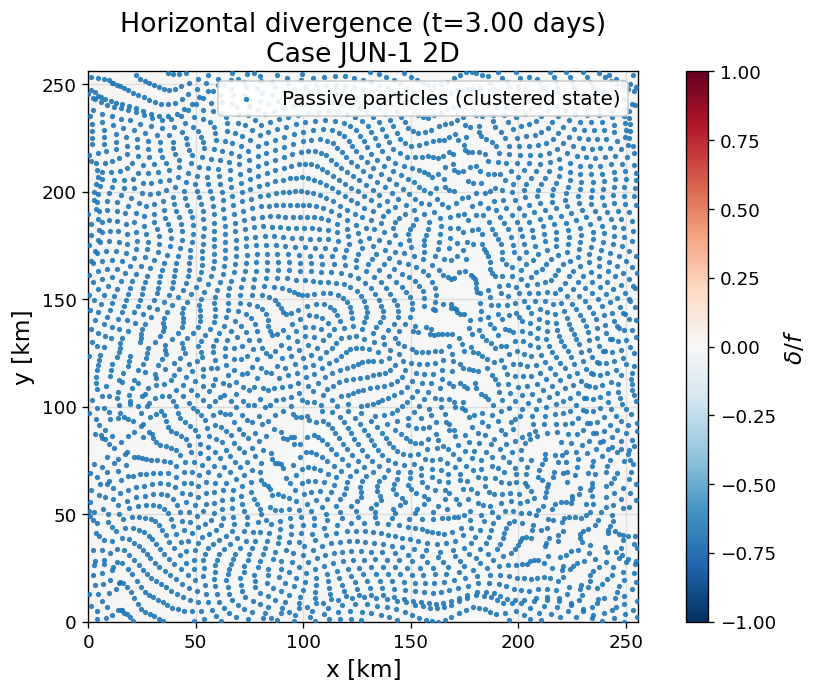

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau6h_k0_obs0024.png


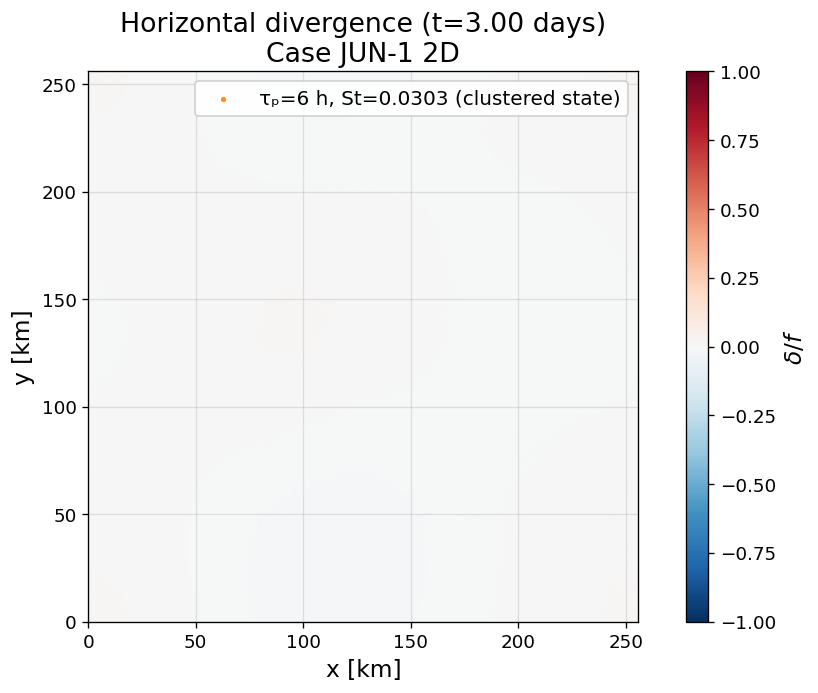

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau12h_k0_obs0024.png


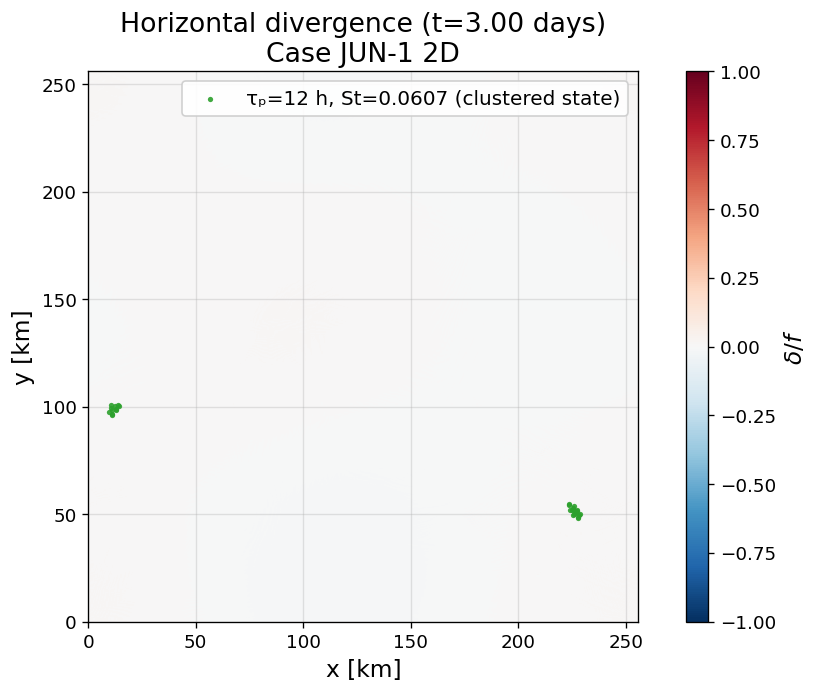

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau1d_k0_obs0024.png


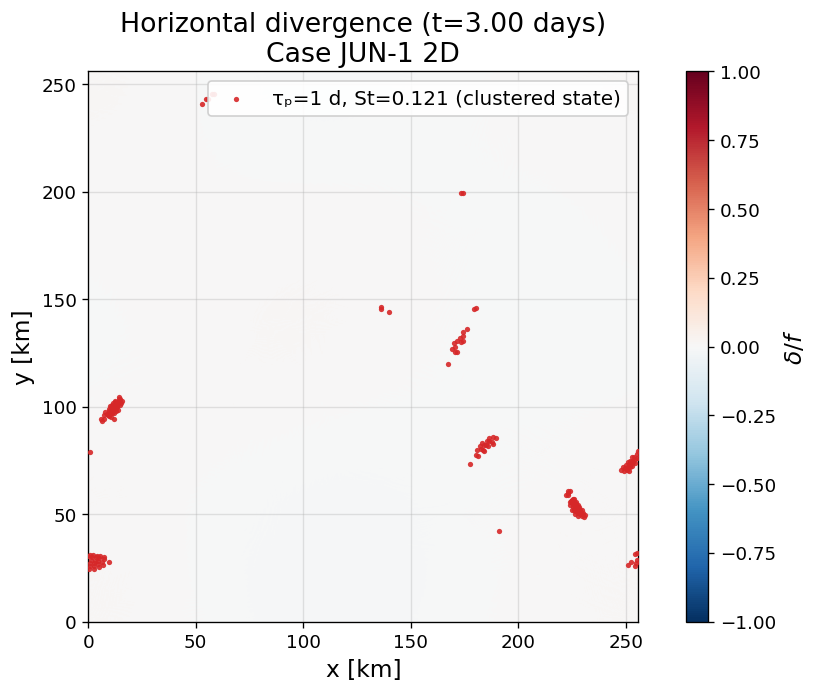

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_passive_k0_obs0040.png


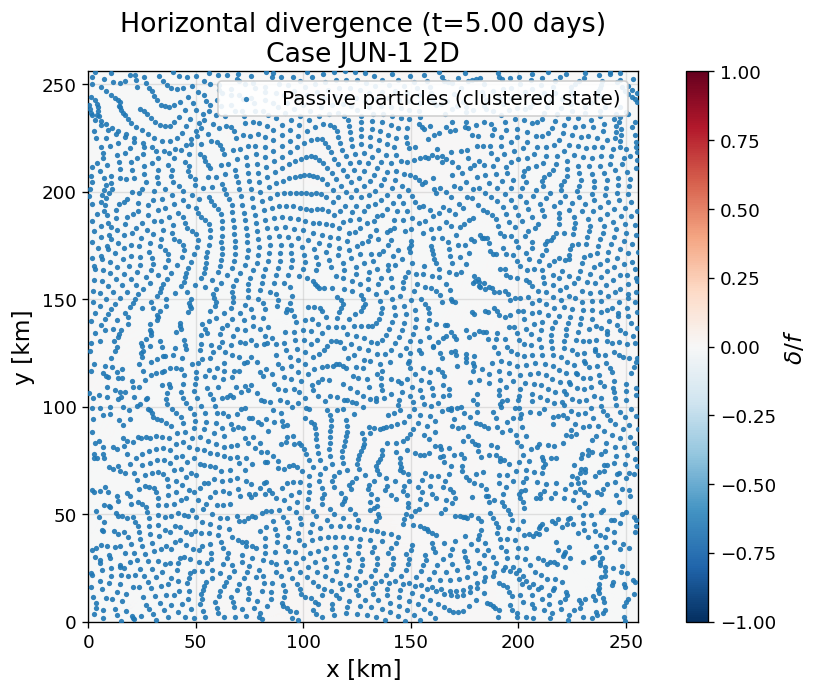

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau6h_k0_obs0040.png


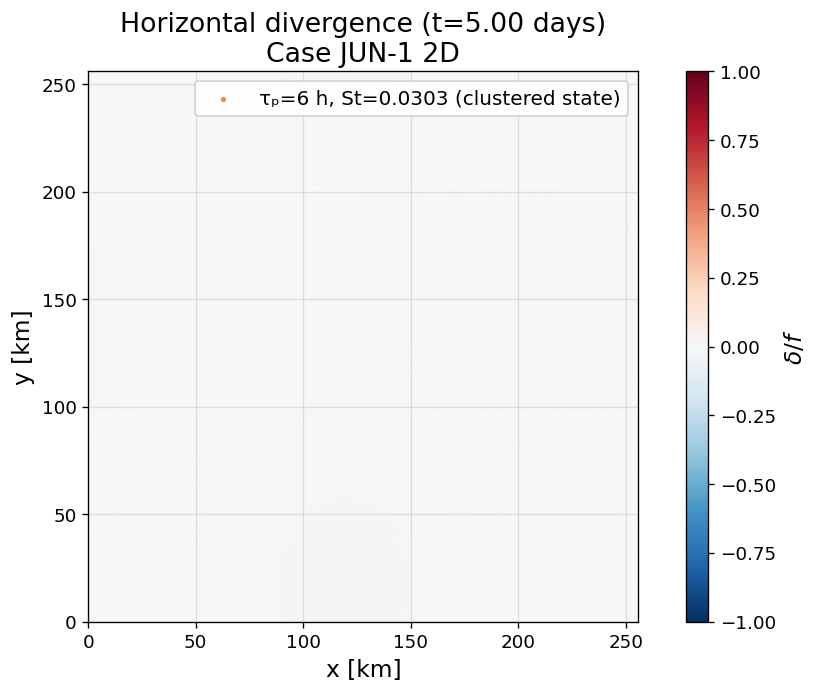

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau12h_k0_obs0040.png


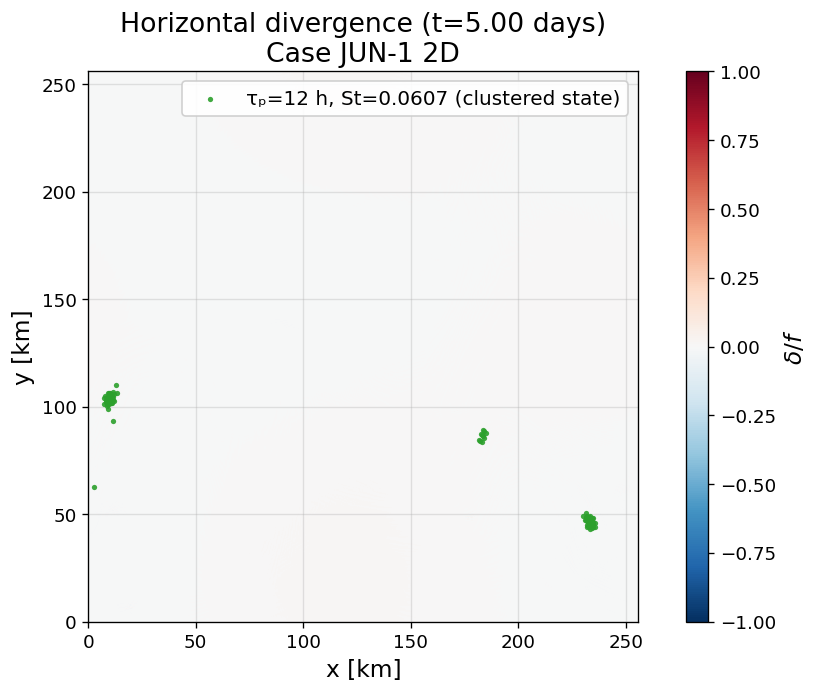

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau1d_k0_obs0040.png


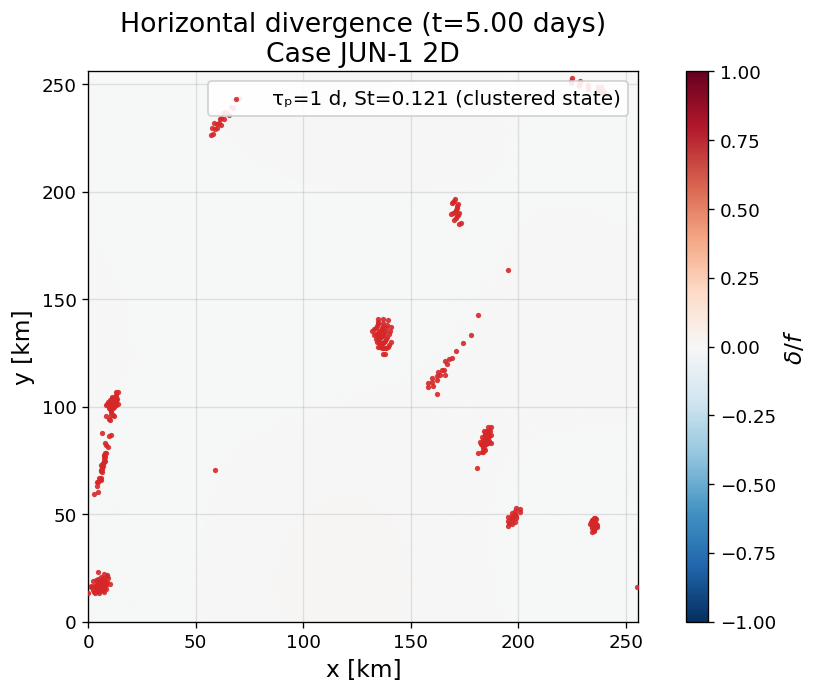

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_passive_k0_obs0064.png


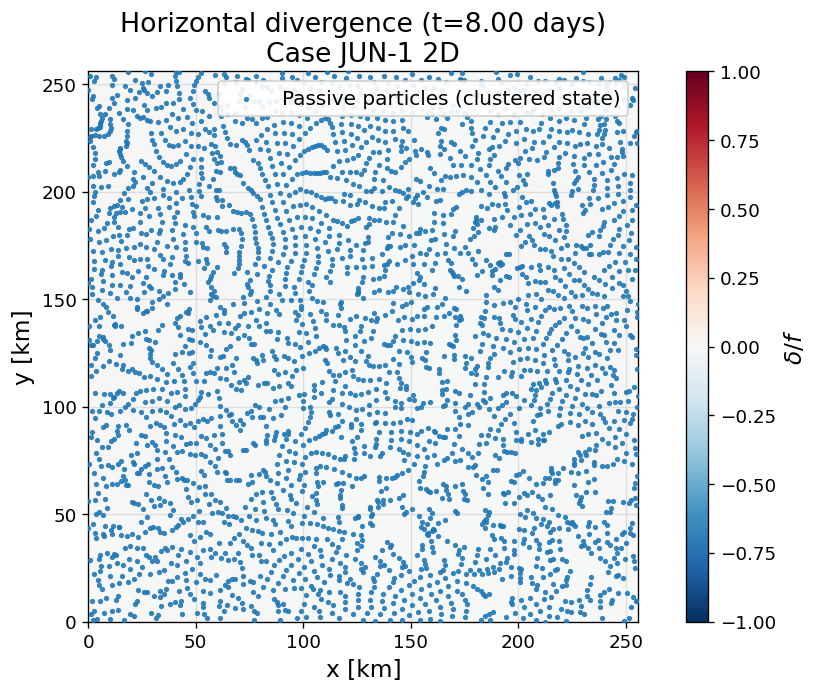

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau6h_k0_obs0064.png


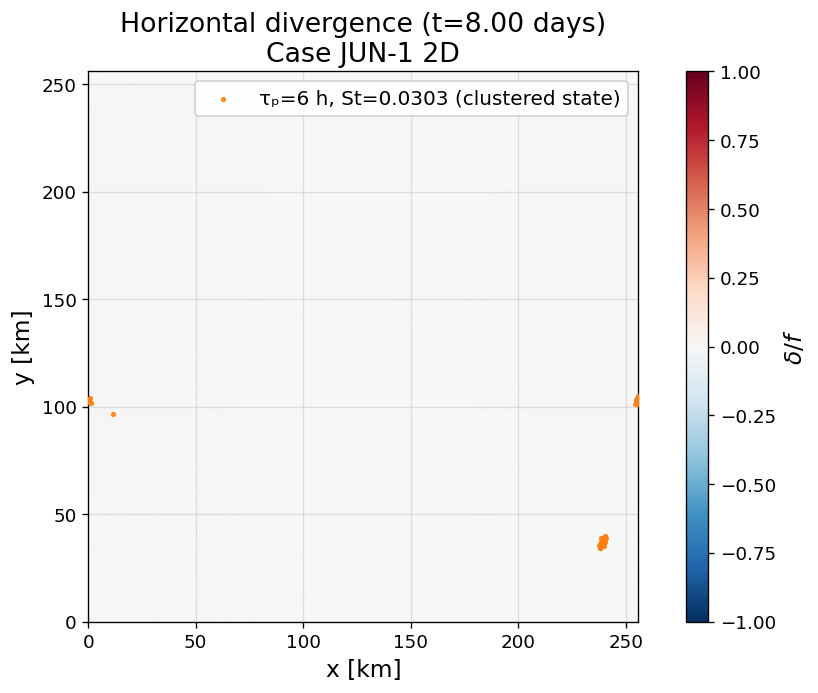

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau12h_k0_obs0064.png


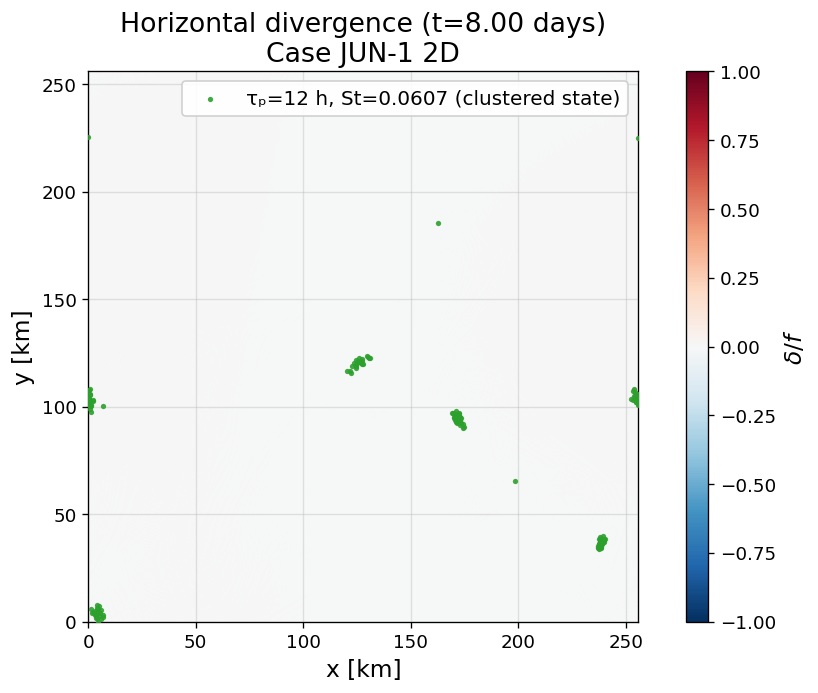

C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\divergence_overlays\div_f_tau1d_k0_obs0064.png


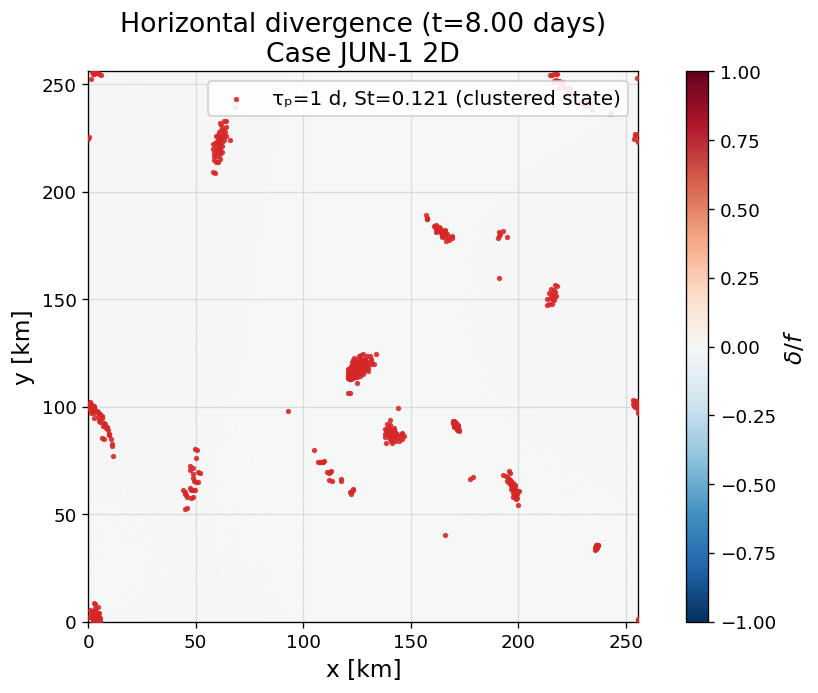

In [9]:
# ============================================================
# 11. FLOW MAPS WITH CLUSTERED PARTICLES ONLY
# ============================================================

if PLOT_ROSSBY_OVERLAYS:
    for obs_idx in snapshot_obs_indices:
        for particle_tag in trajectories:
            phelp.plot_flow_particle_overlay(
                flow_var="ro",
                obs_idx=obs_idx,
                particle_tag=particle_tag,
                coupled_outputs=coupled_outputs,
                class_style_map=class_style_map,
                ds_flow=ds_flow,
                plot_utils=shu,
                plot_theme=ptheme,
                dx=DX,
                dy=DY,
                run_title_info=RUN_TITLE_INFO,
                rossby_limits=ROSSBY_LIMITS,
                divergence_limits=DIVERGENCE_LIMITS,
                plot_only_clustered_particles=PLOT_ONLY_CLUSTERED_PARTICLES,
                show_all_particles_faint=SHOW_ALL_PARTICLES_FAINT,
                use_tolerant_cluster_flag=USE_TOLERANT_CLUSTER_FLAG,
                particle_point_size=PARTICLE_POINT_SIZE,
                particle_point_alpha=PARTICLE_POINT_ALPHA,
                faint_point_alpha=FAINT_POINT_ALPHA,
                save_figures=SAVE_FIGURES,
                coupled_fig_dir=COUPLED_FIG_DIR,
                flow_level_tag=flow_level_tag,
            )

if PLOT_DIVERGENCE_OVERLAYS:
    for obs_idx in snapshot_obs_indices:
        for particle_tag in trajectories:
            phelp.plot_flow_particle_overlay(
                flow_var="div_f",
                obs_idx=obs_idx,
                particle_tag=particle_tag,
                coupled_outputs=coupled_outputs,
                class_style_map=class_style_map,
                ds_flow=ds_flow,
                plot_utils=shu,
                plot_theme=ptheme,
                dx=DX,
                dy=DY,
                run_title_info=RUN_TITLE_INFO,
                rossby_limits=ROSSBY_LIMITS,
                divergence_limits=DIVERGENCE_LIMITS,
                plot_only_clustered_particles=PLOT_ONLY_CLUSTERED_PARTICLES,
                show_all_particles_faint=SHOW_ALL_PARTICLES_FAINT,
                use_tolerant_cluster_flag=USE_TOLERANT_CLUSTER_FLAG,
                particle_point_size=PARTICLE_POINT_SIZE,
                particle_point_alpha=PARTICLE_POINT_ALPHA,
                faint_point_alpha=FAINT_POINT_ALPHA,
                save_figures=SAVE_FIGURES,
                coupled_fig_dir=COUPLED_FIG_DIR,
                flow_level_tag=flow_level_tag,
            )


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\timeseries\local_pro_per_square_vs_cluster_fraction_k0_4x4.png


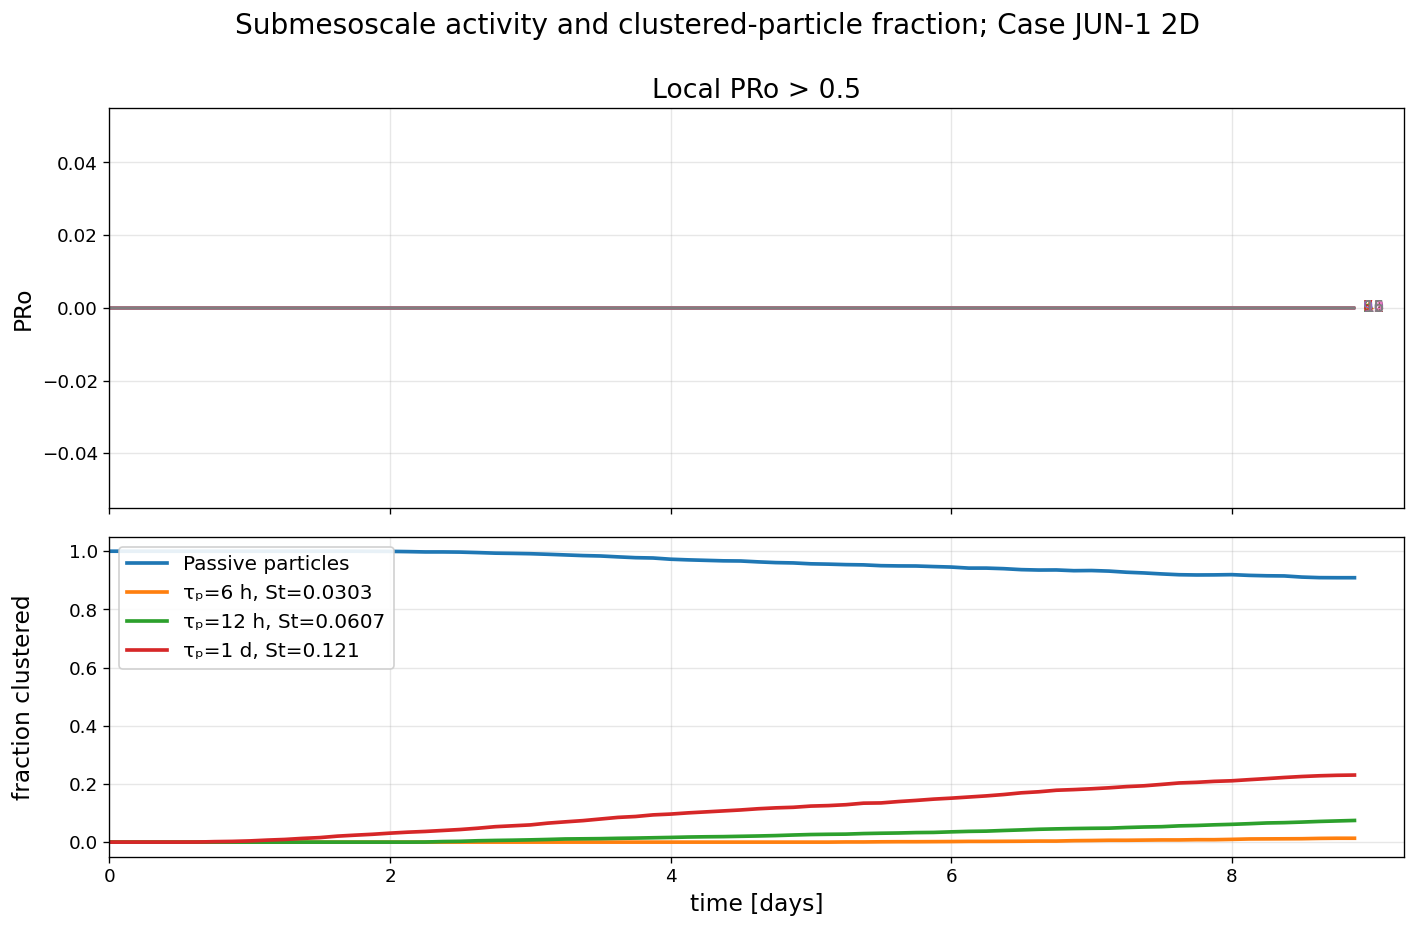

In [10]:
# Same spatial subdivision as in analysis.ipynb.
N_SQUARES_X = 4
N_SQUARES_Y = 4

# ============================================================
# 12. TEMPORAL EVOLUTION:
#     LOCAL SUBMESOSCALE ACTIVITY VS CLUSTER FRACTION
# ============================================================

if PLOT_CLUSTER_FRACTION_VS_SUBMESO_ACTIVITY:

    # --------------------------------------------------------
    # Compute local PRo in the same discretized squares used
    # in analysis.ipynb.
    #
    # PRo = area fraction within a square where |Ro| exceeds
    # the selected threshold.
    # --------------------------------------------------------
    ro_all = np.asarray(ds_flow["ro"].values, dtype=float)
    t_days = np.asarray(ds_flow["elapsed_days"].values, dtype=float)

    _, ny, nx = ro_all.shape

    squares, square_x_edges, square_y_edges = (
        shu.build_square_index_ranges(
            ny,
            nx,
            N_SQUARES_Y,
            N_SQUARES_X,
        )
    )

    square_metrics_records = []

    for j, obs_idx in enumerate(ds_flow["obs"].values):
        square_values = shu.compute_pro_per_square(
            ro_all[j],
            squares,
            SUBMESO_RO_THRESHOLD,
        )

        for result in square_values:
            square_metrics_records.append(
                {
                    "obs": int(obs_idx),
                    "elapsed_days": float(t_days[j]),
                    "square_id": int(result["square_id"]),
                    "PRo": float(result["PRo"]),
                }
            )

    square_metrics_df = pd.DataFrame(square_metrics_records)

    square_pro_wide = (
        square_metrics_df
        .pivot(
            index="elapsed_days",
            columns="square_id",
            values="PRo",
        )
        .sort_index()
    )

    # --------------------------------------------------------
    # Improved two-panel layout
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(13.0, 8.0),
        sharex=True,
        facecolor="white",
        gridspec_kw={
            "height_ratios": [1.25, 1.0],
            "hspace": 0.08,
        },
    )

    fig.suptitle(
        f"Submesoscale activity and clustered-particle fraction; {RUN_TITLE_INFO}",
        y=0.98,
    )

    # --------------------------------------------------------
    # Top panel: local PRo per discretized square
    # --------------------------------------------------------
    ax = axes[0]
    categorical_cmap = shu.get_cmap("categorical")

    for i, square_id in enumerate(square_pro_wide.columns):
        x = np.asarray(square_pro_wide.index.values, dtype=float)
        y = np.asarray(square_pro_wide[square_id].values, dtype=float)

        color = (
            categorical_cmap((i % 20) / 19)
            if callable(categorical_cmap)
            else None
        )

        ax.plot(
            x,
            y,
            color=color,
            lw=1.4,
            alpha=0.90,
        )

        # Add square number at the end of every line, consistent
        # with the local-PRo figure in analysis.ipynb.
        finite = np.isfinite(y)

        if np.any(finite):
            last_index = np.where(finite)[0][-1]

            ax.annotate(
                str(int(square_id)),
                xy=(x[last_index], y[last_index]),
                xytext=(5, 0),
                textcoords="offset points",
                color=color,
                fontsize=getattr(ptheme, "ANNOTATION_SIZE", 10),
                va="center",
                clip_on=False,
            )

    ax.set_ylabel(
        rf"PRo"
    )
    ax.set_title(
        f"Local PRo > 0.5"
    )
    ax.grid(True, alpha=0.30)

    # Leave room on the right for square-number annotations.
    x_min = np.nanmin(square_pro_wide.index.values)
    x_max = np.nanmax(square_pro_wide.index.values)
    x_padding = 0.04 * (x_max - x_min)

    ax.set_xlim(
        x_min,
        x_max + max(x_padding, 0.1),
    )

    # --------------------------------------------------------
    # Bottom panel: fraction of particles in clustered state
    # --------------------------------------------------------
    ax = axes[1]

    for particle_tag, item in coupled_outputs.items():
        ds_c = item["ds"]
        label = item["label"]
        style = class_style_map[particle_tag]
        cvar = phelp.cluster_var_name(ds_c, use_tolerant=USE_TOLERANT_CLUSTER_FLAG)

        cluster_flags = np.asarray(
            ds_c[cvar].values,
            dtype=float,
        )

        fraction_clustered = np.nanmean(
            cluster_flags,
            axis=0,
        )

        ax.plot(
            np.asarray(ds_c["elapsed_days"].values, dtype=float),
            fraction_clustered,
            label=label,
            color=style["color"],
            lw=2.2,
        )

    ax.set_xlabel("time [days]")
    ax.set_ylabel("fraction clustered")
    ax.grid(True, alpha=0.30)

    ax.legend(
        loc="upper left",
        fontsize=getattr(ptheme, "LEGEND_FONTSIZE", 12),
    )

    fig.align_ylabels(axes)
    fig.subplots_adjust(
        left=0.11,
        right=0.94,
        bottom=0.10,
        top=0.88,
    )

    if SAVE_FIGURES:
        out_dir = COUPLED_FIG_DIR / "timeseries"
        out_dir.mkdir(parents=True, exist_ok=True)

        shu.savefig_if_needed(
            fig,
            (
                "local_pro_per_square_vs_cluster_fraction_"
                f"{flow_level_tag}_"
                f"{N_SQUARES_X}x{N_SQUARES_Y}"
            ),
            save=True,
            out_dir=out_dir,
        )

    plt.show()


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\timeseries\area_weighted_voronoi_concentration_by_regime_k0.png


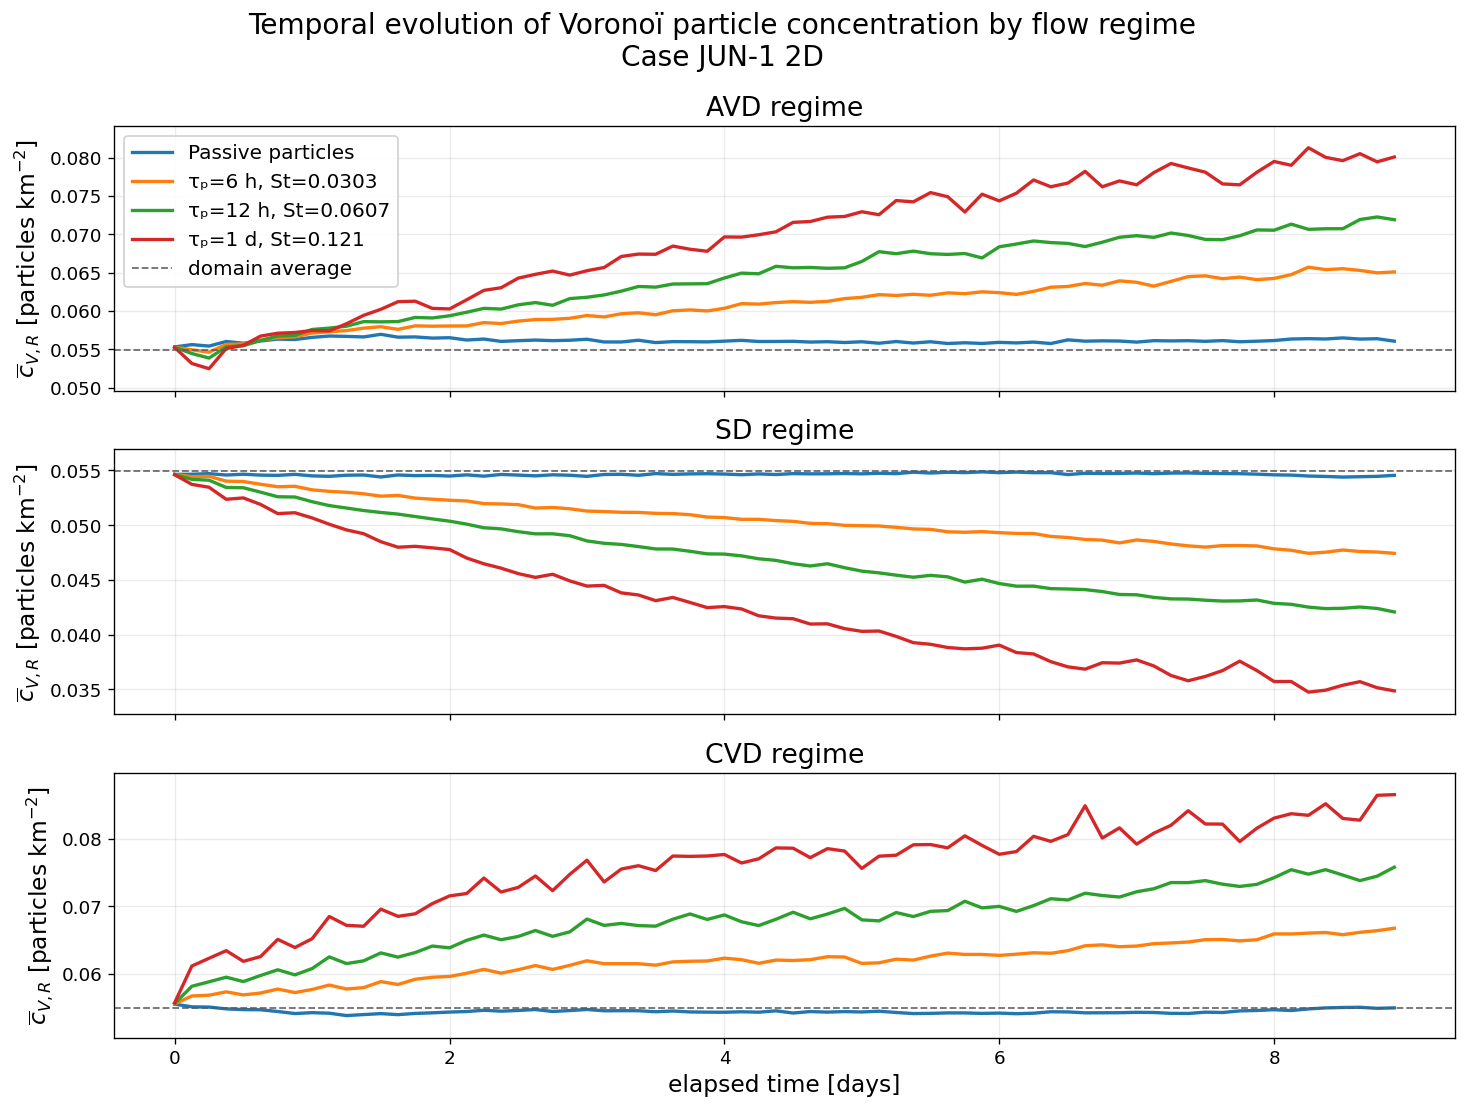

In [11]:
# ============================================================
# 13. TEMPORAL EVOLUTION:
#     AREA-WEIGHTED VORONOÏ CONCENTRATION BY FLOW REGIME
# ============================================================

if PLOT_REGIME_CONCENTRATION_TIMESERIES:

    regimes = ["AVD", "SD", "CVD"]
    regime_concentration = {regime: {} for regime in regimes}

    domain_area_km2 = (Lx * Ly) / 1.0e6

    # --------------------------------------------------------
    # Calculate area-weighted concentration
    # --------------------------------------------------------
    for particle_tag, item in coupled_outputs.items():
        ds_c = item["ds"]

        ro_p = np.asarray(
            ds_c["ro_particle"].values,
            dtype=float,
        )
        strain_p = np.asarray(
            ds_c["strain_f_particle"].values,
            dtype=float,
        )
        area_m2 = np.asarray(
            ds_c["voronoi_area"].values,
            dtype=float,
        )

        for regime_name in regimes:
            concentration = np.full(
                ds_c.sizes["obs"],
                np.nan,
                dtype=float,
            )

            for j in range(ds_c.sizes["obs"]):
                masks = phelp.particle_regime_masks(
                    ro_p[:, j],
                    strain_p[:, j],
                )

                valid = (
                    masks[regime_name]
                    & np.isfinite(area_m2[:, j])
                    & (area_m2[:, j] > 0.0)
                )

                n_particles = int(np.count_nonzero(valid))

                if n_particles == 0:
                    continue

                total_area_km2 = (
                    np.nansum(area_m2[valid, j]) / 1.0e6
                )

                if total_area_km2 > 0.0:
                    concentration[j] = (
                        n_particles / total_area_km2
                    )

            regime_concentration[regime_name][
                particle_tag
            ] = concentration

    # Domain-average reference concentration.
    reference_ds_c = next(iter(coupled_outputs.values()))["ds"]
    domain_mean_concentration = (
        reference_ds_c.sizes["trajectory"]
        / domain_area_km2
    )

    # --------------------------------------------------------
    # Plot with a separate linear scale for each regime
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        len(regimes),
        1,
        figsize=(13.0, 9.5),
        sharex=True,
        sharey=False,
        facecolor="white",
        gridspec_kw={"hspace": 0.22},
    )

    fig.suptitle(
        "Temporal evolution of Voronoï "
        "particle concentration by flow regime\n"
        f"{RUN_TITLE_INFO}",
        y=0.98,
    )

    for ax, regime_name in zip(axes, regimes):

        regime_values = []

        for particle_tag, item in coupled_outputs.items():
            ds_c = item["ds"]
            style = class_style_map[particle_tag]

            values = regime_concentration[
                regime_name
            ][particle_tag]

            ax.plot(
                np.asarray(
                    ds_c["elapsed_days"].values,
                    dtype=float,
                ),
                values,
                color=style["color"],
                lw=2.0,
                label=item["label"],
            )

            finite_values = values[np.isfinite(values)]

            if finite_values.size:
                regime_values.append(finite_values)

        # Domain-average concentration reference.
        ax.axhline(
            domain_mean_concentration,
            color="0.35",
            lw=1.1,
            ls="--",
            alpha=0.85,
            label="domain average",
        )

        # Tight, regime-specific linear y limits.
        if regime_values:
            regime_values = np.concatenate(regime_values)

            y_min = min(
                float(np.nanmin(regime_values)),
                domain_mean_concentration,
            )
            y_max = max(
                float(np.nanmax(regime_values)),
                domain_mean_concentration,
            )

            y_range = y_max - y_min
            y_padding = (
                0.10 * y_range
                if y_range > 0.0
                else 0.01 * max(abs(y_max), 1.0)
            )

            ax.set_ylim(
                max(0.0, y_min - y_padding),
                y_max + y_padding,
            )

        ax.set_title(f"{regime_name} regime")
        ax.set_ylabel(
            r"$\overline{c}_{V,R}$ "
            r"[particles km$^{-2}$]"
        )
        ax.ticklabel_format(
            axis="y",
            style="plain",
            useOffset=False,
        )
        ax.grid(True, alpha=0.25)

    axes[0].legend(loc="upper left")
    axes[-1].set_xlabel("elapsed time [days]")

    fig.subplots_adjust(
        left=0.11,
        right=0.97,
        bottom=0.08,
        top=0.88,
    )

    if SAVE_FIGURES:
        out_dir = COUPLED_FIG_DIR / "timeseries"
        out_dir.mkdir(parents=True, exist_ok=True)

        shu.savefig_if_needed(
            fig,
            (
                "area_weighted_voronoi_concentration_"
                f"by_regime_{flow_level_tag}"
            ),
            save=True,
            out_dir=out_dir,
        )

    plt.show()

In [12]:
# ============================================================
# SHARED PREPARATION FOR ROSSBY–STRAIN SUMMARY FIGURES
# ============================================================

from scipy.ndimage import gaussian_filter

# Select snapshot and particle class.
OBS_IDX = snapshot_obs_indices[0]
PARTICLE_TAG = list(coupled_outputs.keys())[0]

# Use a resolution close to the original Eulerian JPDF.
RS_NBINS = 100
RS_RO_LIMITS = (-0.25, 0.50)
RS_STRAIN_LIMITS = (0.00, 0.50)

# Light smoothing only for the displayed particle histogram.
# The particle positions and regime-enrichment calculation remain unsmoothed.
PARTICLE_DISPLAY_SMOOTHING = 0.7

ro_edges_rs = np.linspace(
    RS_RO_LIMITS[0],
    RS_RO_LIMITS[1],
    RS_NBINS + 1,
)

strain_edges_rs = np.linspace(
    RS_STRAIN_LIMITS[0],
    RS_STRAIN_LIMITS[1],
    RS_NBINS + 1,
)

ds_c = coupled_outputs[PARTICLE_TAG]["ds"]
particle_label = coupled_outputs[PARTICLE_TAG]["label"]
particle_style = class_style_map[PARTICLE_TAG]

elapsed_days = phelp.get_elapsed_time_days(
    reference_ds,
    OBS_IDX,
)

# ------------------------------------------------------------
# Eulerian flow samples
# ------------------------------------------------------------
ro_flow = np.asarray(
    ds_flow["ro"].isel(obs=OBS_IDX).values,
    dtype=float,
).ravel()

strain_flow = np.asarray(
    ds_flow["strain_f"].isel(obs=OBS_IDX).values,
    dtype=float,
).ravel()

valid_flow = (
    np.isfinite(ro_flow)
    & np.isfinite(strain_flow)
)

# ------------------------------------------------------------
# Particle-sampled flow properties
# ------------------------------------------------------------
ro_particle = np.asarray(
    ds_c["ro_particle"].isel(obs=OBS_IDX).values,
    dtype=float,
).ravel()

strain_particle = np.asarray(
    ds_c["strain_f_particle"].isel(obs=OBS_IDX).values,
    dtype=float,
).ravel()

valid_particle = (
    np.isfinite(ro_particle)
    & np.isfinite(strain_particle)
)

# ------------------------------------------------------------
# Common-bin probability distributions
# ------------------------------------------------------------
flow_counts, _, _ = np.histogram2d(
    ro_flow[valid_flow],
    strain_flow[valid_flow],
    bins=[ro_edges_rs, strain_edges_rs],
)

particle_counts, _, _ = np.histogram2d(
    ro_particle[valid_particle],
    strain_particle[valid_particle],
    bins=[ro_edges_rs, strain_edges_rs],
)

flow_probability = (
    flow_counts / np.sum(flow_counts)
)

# Smooth only for display to reduce empty-bin pixelation.
particle_counts_display = gaussian_filter(
    particle_counts.astype(float),
    sigma=PARTICLE_DISPLAY_SMOOTHING,
    mode="nearest",
)

particle_probability_display = (
    particle_counts_display
    / np.sum(particle_counts_display)
)

def _log_relative_probability(probability):
    result = np.full_like(
        probability,
        np.nan,
        dtype=float,
    )

    maximum = np.nanmax(probability)

    if np.isfinite(maximum) and maximum > 0.0:
        positive = probability > 0.0
        result[positive] = np.log10(
            probability[positive] / maximum
        )

    return result

flow_log_relative = _log_relative_probability(
    flow_probability
)

particle_log_relative = _log_relative_probability(
    particle_probability_display
)

# ------------------------------------------------------------
# Regime enrichment:
#
# E_R = particle fraction in R / Eulerian flow fraction in R
# ------------------------------------------------------------
def _regime_fractions(ro, strain):
    ro = np.asarray(ro, dtype=float)
    strain = np.asarray(strain, dtype=float)

    valid = (
        np.isfinite(ro)
        & np.isfinite(strain)
    )

    masks = {
        "AVD": (
            valid
            & (ro < 0.0)
            & (strain < np.abs(ro))
        ),
        "SD": (
            valid
            & (strain >= np.abs(ro))
        ),
        "CVD": (
            valid
            & (ro > 0.0)
            & (strain < np.abs(ro))
        ),
    }

    n_valid = np.count_nonzero(valid)

    return {
        regime: (
            np.count_nonzero(mask) / n_valid
            if n_valid > 0
            else np.nan
        )
        for regime, mask in masks.items()
    }

flow_regime_fraction = _regime_fractions(
    ro_flow,
    strain_flow,
)

particle_regime_fraction = _regime_fractions(
    ro_particle,
    strain_particle,
)

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\figures\coupled_flow_particle\summary_ro_strain\flow_jpdf_particle_samples_passive_k0_obs0008.png


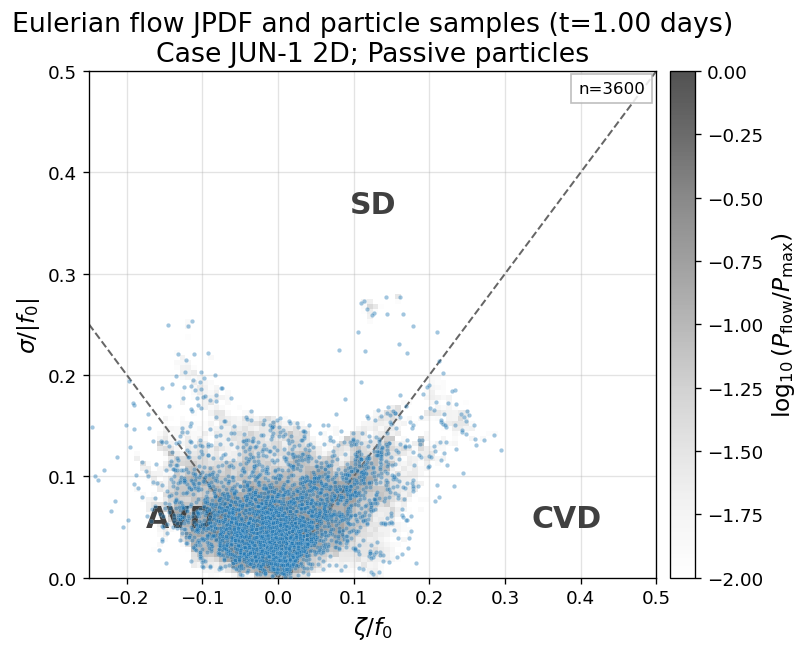

In [13]:
# ============================================================
# SINGLE PANEL:
# EULERIAN FLOW JPDF + INDIVIDUAL PARTICLE SAMPLES
# ============================================================

fig, ax = plt.subplots(
    figsize=shu.get_figsize("map"),
    facecolor="white",
)

ax.set_facecolor("white")

# Muted Eulerian background.
pcm = ax.pcolormesh(
    ro_edges_rs,
    strain_edges_rs,
    flow_log_relative.T,
    shading="auto",
    cmap="Greys",
    vmin=-2.0,
    vmax=0.0,
    alpha=0.68,
)

# White-edged, class-colored points remain visible on both
# dark and light parts of the JPDF.
ax.scatter(
    ro_particle[valid_particle],
    strain_particle[valid_particle],
    s=7,
    facecolor=particle_style["color"],
    edgecolor="white",
    linewidth=0.18,
    alpha=0.42,
    rasterized=True,
    zorder=4,
)

phelp.draw_ro_strain_regime_guides(
    ax,
    x_min=ro_edges_rs[0],
    x_max=ro_edges_rs[-1],
    y_max=strain_edges_rs[-1],
)

ax.set_xlim(
    ro_edges_rs[0],
    ro_edges_rs[-1],
)

ax.set_ylim(
    strain_edges_rs[0],
    strain_edges_rs[-1],
)

ax.set_xlabel(r"$\zeta/f_0$")
ax.set_ylabel(r"$\sigma/|f_0|$")

ax.set_title(
    f"Eulerian flow JPDF and particle samples "
    f"(t={elapsed_days:.2f} days)\n"
    f"{RUN_TITLE_INFO}; {particle_label}"
)

ax.text(
    0.98,
    0.98,
    f"n={np.count_nonzero(valid_particle)}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=getattr(
        ptheme,
        "ANNOTATION_SIZE",
        10,
    ),
    bbox={
        "facecolor": "white",
        "edgecolor": "0.7",
        "alpha": 0.85,
    },
)

cbar = fig.colorbar(
    pcm,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    r"$\log_{10}(P_{\mathrm{flow}}/P_{\max})$"
)

fig.tight_layout(
    rect=(0.0, 0.055, 1.0, 1.0)
)

if SAVE_FIGURES:
    out_dir = (
        COUPLED_FIG_DIR
        / "summary_ro_strain"
    )
    out_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    shu.savefig_if_needed(
        fig,
        (
            "flow_jpdf_particle_samples_"
            f"{PARTICLE_TAG}_{flow_level_tag}_"
            f"obs{OBS_IDX:04d}"
        ),
        save=True,
        out_dir=out_dir,
    )

plt.show()

In [ ]:
RS_NBINS = 100
RS_RO_LIMITS = (-0.25, 0.50)
RS_STRAIN_LIMITS = (0.00, 0.50)

FLOW_CMAP = "turbo"
FLOW_VMIN = -2.0
FLOW_VMAX = 0.0

GRAY_CMAP = "Greys"
GRAY_ALPHA = 0.65

PARTICLE_SIZE = 6
PARTICLE_ALPHA = 0.40
PARTICLE_EDGEWIDTH = 0.0


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def _isel_snapshot(da, obs_idx):
    if "obs" in da.dims:
        return da.isel(obs=obs_idx)
    elif "time" in da.dims:
        return da.isel(time=obs_idx)
    else:
        return da

def _log_relative_probability(probability):
    result = np.full_like(probability, np.nan, dtype=float)
    pmax = np.nanmax(probability)
    if np.isfinite(pmax) and pmax > 0.0:
        mask = probability > 0.0
        result[mask] = np.log10(probability[mask] / pmax)
    return result

def _draw_regime_guides(ax, xlim, ylim):
    x = np.linspace(xlim[0], xlim[1], 500)

    # regime boundaries: sigma = |zeta|
    ax.plot(x[x <= 0], -x[x <= 0], ls="--", lw=1.5, color="0.35", alpha=0.85, zorder=3)
    ax.plot(x[x >= 0],  x[x >= 0], ls="--", lw=1.5, color="0.35", alpha=0.85, zorder=3)

    # regime labels
    ax.text(-0.18, 0.055, "AVD", fontsize=18, color="0.25", weight="bold")
    ax.text( 0.03, 0.36,  "SD",  fontsize=18, color="0.25", weight="bold")
    ax.text( 0.31, 0.055, "CVD", fontsize=18, color="0.25", weight="bold")


# ------------------------------------------------------------
# LOAD FLOW SNAPSHOT
# ------------------------------------------------------------
ro_flow = np.asarray(_isel_snapshot(ds_flow["ro"], OBS_IDX).values, dtype=float).ravel()
strain_flow = np.asarray(_isel_snapshot(ds_flow["strain_f"], OBS_IDX).values, dtype=float).ravel()

valid_flow = np.isfinite(ro_flow) & np.isfinite(strain_flow)
ro_flow = ro_flow[valid_flow]
strain_flow = strain_flow[valid_flow]

# ------------------------------------------------------------
# LOAD PARTICLE SNAPSHOT
# ------------------------------------------------------------
ds_c = coupled_outputs[SUMMARY_PARTICLE_TAG]["ds"]
particle_label = coupled_outputs[SUMMARY_PARTICLE_TAG]["label"]
particle_style = class_style_map[SUMMARY_PARTICLE_TAG]

ro_particle = np.asarray(ds_c["ro_particle"].isel(obs=OBS_IDX).values, dtype=float).ravel()
strain_particle = np.asarray(ds_c["strain_f_particle"].isel(obs=OBS_IDX).values, dtype=float).ravel()

valid_particle = np.isfinite(ro_particle) & np.isfinite(strain_particle)
ro_particle = ro_particle[valid_particle]
strain_particle = strain_particle[valid_particle]

# elapsed time
if "elapsed_days" in ds_c:
    elapsed_days = float(ds_c["elapsed_days"].isel(obs=OBS_IDX).values)
else:
    elapsed_days = float(phelp.get_elapsed_time_days(reference_ds, OBS_IDX))

# ------------------------------------------------------------
# COMMON BINS / JPDF
# ------------------------------------------------------------
ro_edges = np.linspace(RS_RO_LIMITS[0], RS_RO_LIMITS[1], RS_NBINS + 1)
strain_edges = np.linspace(RS_STRAIN_LIMITS[0], RS_STRAIN_LIMITS[1], RS_NBINS + 1)

flow_counts, _, _ = np.histogram2d(
    ro_flow,
    strain_flow,
    bins=[ro_edges, strain_edges],
)

flow_probability = flow_counts / np.sum(flow_counts)
flow_log_relative = _log_relative_probability(flow_probability)

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(14.5, 6.3),
    sharex=True,
    sharey=True,
    facecolor="white",
)

fig.suptitle(
    f"Flow and particle distribution in Vorticity–strain space (t={elapsed_days:.2f} days)\n"
    f"{RUN_TITLE_INFO}; {particle_label}",
    y=0.9
)

# ============================================================
# LEFT PANEL: usual Eulerian JPDF
# ============================================================
ax = axes[0]
ax.set_facecolor("white")

pcm0 = ax.pcolormesh(
    ro_edges,
    strain_edges,
    flow_log_relative.T,
    shading="auto",
    cmap=FLOW_CMAP,
    vmin=FLOW_VMIN,
    vmax=FLOW_VMAX,
)

_draw_regime_guides(ax, RS_RO_LIMITS, RS_STRAIN_LIMITS)

ax.set_title("Eulerian flow JPDF")
ax.set_xlim(RS_RO_LIMITS)
ax.set_ylim(RS_STRAIN_LIMITS)
ax.set_xlabel(r"$\zeta/f_0$")
ax.set_ylabel(r"$\sigma/|f_0|$")

cbar0 = fig.colorbar(pcm0, ax=ax, pad=0.02)
cbar0.set_label(r"$\log_{10}(P_{\mathrm{flow}}/P_{\max})$")

# ============================================================
# RIGHT PANEL: particles over grayscale JPDF
# ============================================================
ax = axes[1]
ax.set_facecolor("white")

pcm1 = ax.pcolormesh(
    ro_edges,
    strain_edges,
    flow_log_relative.T,
    shading="auto",
    cmap=GRAY_CMAP,
    vmin=FLOW_VMIN,
    vmax=FLOW_VMAX,
    alpha=GRAY_ALPHA,
)

ax.scatter(
    ro_particle,
    strain_particle,
    s=PARTICLE_SIZE,
    color=particle_style["color"],
    alpha=PARTICLE_ALPHA,
    linewidths=PARTICLE_EDGEWIDTH,
    zorder=4,
    label=particle_label,
)

_draw_regime_guides(ax, RS_RO_LIMITS, RS_STRAIN_LIMITS)

ax.set_title("Particle samples")
ax.set_xlim(RS_RO_LIMITS)
ax.set_ylim(RS_STRAIN_LIMITS)
ax.set_xlabel(r"$\zeta/f_0$")

# small n-box like your preferred figure
ax.text(
    0.985, 0.985,
    f"n={ro_particle.size}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.9)
)

ax.legend(loc="upper right", framealpha=0.95)

cbar1 = fig.colorbar(pcm1, ax=ax, pad=0.02)
cbar1.set_label(r"$\log_{10}(P_{\mathrm{flow}}/P_{\max})$")

fig.tight_layout(rect=(0, 0, 1, 0.94))

if SAVE_FIGURES:
    out_dir = COUPLED_FIG_DIR / "summary_ro_strain"
    out_dir.mkdir(parents=True, exist_ok=True)
    shu.savefig_if_needed(
        fig,
        f"flow_jpdf_and_particle_samples_{SUMMARY_PARTICLE_TAG}_{flow_level_tag}_obs{OBS_IDX:04d}",
        save=True,
        out_dir=out_dir,
    )

plt.show()

NameError: name 'SUMMARY_PARTICLE_TAG' is not defined